# Statistical analysis of XAI narrative evaluations

Cross-experiment statistical analysis covering all four experiments:
- TokenSHAP × German Credit
- TokenSHAP × Stroke
- MExGen × German Credit
- MExGen × Stroke

All tests operate on the majority-voted `final_score` per (experiment, instance, persona, judge, aspect), and on the cross-judge majority-voted `aggregated_score`.

Outputs:
- Inline tables and printed test results in each cell
- One CSV per analysis section under `analysis_outputs/csv/`
- A consolidated markdown summary at `analysis_outputs/summary.md`

## Section 0 - Setup

In [1]:
import json
import os
import pickle
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.precision", 4)

OUT_DIR = Path("analysis_outputs")
CSV_DIR = OUT_DIR / "csv"
OUT_DIR.mkdir(exist_ok=True)
CSV_DIR.mkdir(exist_ok=True)

MARKDOWN_LINES: list[str] = []

def md(line: str = "") -> None:
    """Append a line to the running markdown summary."""
    MARKDOWN_LINES.append(line)

def save_csv(df: pd.DataFrame, name: str) -> None:
    path = CSV_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"  -> saved {path}")

md("# Statistical analysis summary\n")
md("Generated by `statistical_analysis.ipynb`.\n")

In [2]:
# -------------------------------------------------------------------------
# Experiment configuration
# -------------------------------------------------------------------------

EXPERIMENTS = {
    "tokenshap_gc": {
        "method": "TokenSHAP",
        "use_case": "German Credit",
        "log": "../TokenSHAP/german_credit/german_credit_log.json",
        "pkl_dir": "../TokenSHAP/german_credit/tokenshap_results",
    },
    "tokenshap_stroke": {
        "method": "TokenSHAP",
        "use_case": "Stroke",
        "log": "../TokenSHAP/stroke/stroke_log.json",
        "pkl_dir": "../TokenSHAP/stroke/tokenshap_results",
    },
    "mexgen_gc": {
        "method": "MExGen",
        "use_case": "German Credit",
        "log": "../MExGen/german_credit/german_credit_log.json",
        "pkl_dir": "../MExGen/german_credit/mexgen_results",
    },
    "mexgen_stroke": {
        "method": "MExGen",
        "use_case": "Stroke",
        "log": "../MExGen/stroke/stroke_log.json",
        "pkl_dir": "../MExGen/stroke/mexgen_results",
    },
}

JUDGE_MODELS = [
    "openai/gpt-5.4",
    "google/gemini-3.1-pro-preview",
    "anthropic/claude-sonnet-4.6",
    "x-ai/grok-4.20",
]

JUDGE_ASPECTS = ["faithfulness", "helpfulness", "plausibility"]

# Short labels for plots/tables
JUDGE_SHORT = {
    "openai/gpt-5.4": "gpt-5.4",
    "google/gemini-3.1-pro-preview": "gemini-3.1-pro",
    "anthropic/claude-sonnet-4.6": "claude-sonnet-4.6",
    "x-ai/grok-4.20": "grok-4.20",
}

In [3]:
# -------------------------------------------------------------------------
# Loader: build a tidy long-format DataFrame from the four logs
# -------------------------------------------------------------------------
# Two DataFrames are produced:
#
# DF      — per-judge data (one row per experiment x instance x persona x judge x aspect).
#           Used for tests that compare judges.
#
# AGG_DF  — the pipeline-computed `aggregate_score` per cell. One row per
#           experiment x instance x persona x aspect. This is the majority vote across the
#           four per-judge final_scores (with ties broken by mean of tied modes).
#           Used this for tests that need a single per-narrative-cell score.
#
# `aggregate_score` is preserved un-rounded — a value of 4.5 indicates that the
# four judges split into a 2-2 tie between scores 4 and 5 and the half-integer
# is more honest than rounding which silently picks a winner.

def load_log(path: str) -> list[dict]:
    if not os.path.exists(path):
        print(f"  ! missing log: {path}")
        return []
    with open(path, "r") as f:
        return json.load(f)

def tidy_from_log(experiment: str, method: str, use_case: str, log: list[dict]):
    """Return (per_judge_rows, aggregate_rows)."""
    per_judge_rows = []
    agg_rows = []
    for entry in log:
        instance = entry.get("instance_index")
        evaluations = entry.get("evaluations", {})
        for persona, aspects in evaluations.items():
            for aspect in JUDGE_ASPECTS:
                judge_dict = aspects.get(aspect, {})
                # Per-judge final_score
                for judge in JUDGE_MODELS:
                    j = judge_dict.get(judge, {})
                    score = j.get("final_score") if isinstance(j, dict) else None
                    per_judge_rows.append({
                        "experiment": experiment,
                        "method": method,
                        "use_case": use_case,
                        "instance": instance,
                        "persona": persona,
                        "judge": judge,
                        "aspect": aspect,
                        "score": float(score) if score is not None else np.nan,
                    })
                # Pipeline aggregate score
                agg = judge_dict.get("aggregate_score")
                agg_rows.append({
                    "experiment": experiment,
                    "method": method,
                    "use_case": use_case,
                    "instance": instance,
                    "persona": persona,
                    "aspect": aspect,
                    "aggregate_score": float(agg) if agg is not None else np.nan,
                })
    return pd.DataFrame(per_judge_rows), pd.DataFrame(agg_rows)

frames_judge = []
frames_agg = []
for exp_name, cfg in EXPERIMENTS.items():
    log = load_log(cfg["log"])
    if log:
        df_j, df_a = tidy_from_log(exp_name, cfg["method"], cfg["use_case"], log)
        print(f"  {exp_name}: {len(df_j)} per-judge rows, {len(df_a)} aggregate rows from {len(log)} log entries")
        frames_judge.append(df_j)
        frames_agg.append(df_a)

if not frames_judge:
    raise FileNotFoundError("No log files were loaded. Update the paths in EXPERIMENTS.")

DF = pd.concat(frames_judge, ignore_index=True)
DF["judge_short"] = DF["judge"].map(JUDGE_SHORT)

AGG_DF = pd.concat(frames_agg, ignore_index=True)

print(f"\nDF: {len(DF)} rows, {DF['score'].notna().sum()} non-null scores")
print(f"AGG_DF: {len(AGG_DF)} rows, {AGG_DF['aggregate_score'].notna().sum()} non-null aggregate scores")
n_half = ((AGG_DF["aggregate_score"] % 1) != 0).sum()
print(f"  Of these aggregates, {n_half} are non-integer (i.e. tie-broken half-integers)")
DF.head()

  tokenshap_gc: 720 per-judge rows, 180 aggregate rows from 20 log entries
  tokenshap_stroke: 1200 per-judge rows, 300 aggregate rows from 20 log entries
  mexgen_gc: 360 per-judge rows, 90 aggregate rows from 10 log entries
  mexgen_stroke: 600 per-judge rows, 150 aggregate rows from 10 log entries

DF: 2880 rows, 2880 non-null scores
AGG_DF: 720 rows, 720 non-null aggregate scores
  Of these aggregates, 335 are non-integer (i.e. tie-broken half-integers)


,experiment,method,use_case,instance,persona,judge,aspect,score,judge_short
0,tokenshap_gc,TokenSHAP,German Credit,0,expert_judge,openai/gpt-5.4,faithfulness,2.0,gpt-5.4
1,tokenshap_gc,TokenSHAP,German Credit,0,expert_judge,google/gemini-3.1-pro-preview,faithfulness,5.0,gemini-3.1-pro
2,tokenshap_gc,TokenSHAP,German Credit,0,expert_judge,anthropic/claude-sonnet-4.6,faithfulness,4.0,claude-sonnet-4.6
3,tokenshap_gc,TokenSHAP,German Credit,0,expert_judge,x-ai/grok-4.20,faithfulness,5.0,grok-4.20
4,tokenshap_gc,TokenSHAP,German Credit,0,expert_judge,openai/gpt-5.4,helpfulness,3.0,gpt-5.4


In [4]:
def kendalls_w(data: np.ndarray) -> float:
    """Kendall's W (coefficient of concordance) effect size for Friedman test.

    data: shape (n_subjects, n_conditions). W = chi2 / (n * (k - 1)).
    """
    n, k = data.shape
    if n < 2 or k < 2:
        return np.nan
    try:
        chi2, _ = stats.friedmanchisquare(*[data[:, c] for c in range(k)])
    except ValueError:
        return np.nan
    return chi2 / (n * (k - 1))

def holm_correct(p_values: list[float]) -> list[float]:
    """Holm-Bonferroni correction. Returns adjusted p-values, NaNs preserved."""
    arr = np.array(p_values, dtype=float)
    valid_idx = np.where(~np.isnan(arr))[0]
    if len(valid_idx) == 0:
        return list(arr)
    valid_p = arr[valid_idx]
    m = len(valid_p)
    order = np.argsort(valid_p)
    adjusted_sorted = np.empty(m)
    running_max = 0.0
    for rank, i in enumerate(order):
        adj = (m - rank) * valid_p[i]
        running_max = max(running_max, min(adj, 1.0))
        adjusted_sorted[i] = running_max
    out = arr.copy()
    out[valid_idx] = adjusted_sorted
    return list(out)

def cliffs_delta(x: np.ndarray, y: np.ndarray) -> float:
    """Cliff's delta effect size. Positive = x > y dominantly."""
    x = np.asarray(x)
    y = np.asarray(y)
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return np.nan
    greater = sum(1 for a in x for b in y if a > b)
    less = sum(1 for a in x for b in y if a < b)
    return (greater - less) / (n_x * n_y)

## Section 1 - Data overview

Sanity-check the data shape, missingness, and basic distribution before any tests are run.

In [5]:
# 1.1 Counts per experiment
counts = (
    DF.groupby(["experiment", "method", "use_case"])
    .agg(
        n_instances=("instance", "nunique"),
        n_personas=("persona", "nunique"),
        n_judges=("judge", "nunique"),
        n_aspects=("aspect", "nunique"),
        n_rows=("score", "size"),
        n_scores=("score", "count"),
        n_missing=("score", lambda s: s.isna().sum()),
    )
    .reset_index()
)
print("Experiment shape")
print(counts.to_string(index=False))
save_csv(counts, "01_experiment_shape")

md("## Section 1 — Data overview\n")
md("### Experiment shape\n")
md(counts.to_markdown(index=False))
md("")

Experiment shape
      experiment    method      use_case  n_instances  n_personas  n_judges  n_aspects  n_rows  n_scores  n_missing
       mexgen_gc    MExGen German Credit           10           3         4          3     360       360          0
   mexgen_stroke    MExGen        Stroke           10           5         4          3     600       600          0
    tokenshap_gc TokenSHAP German Credit           20           3         4          3     720       720          0
tokenshap_stroke TokenSHAP        Stroke           20           5         4          3    1200      1200          0
  -> saved analysis_outputs\csv\01_experiment_shape.csv


In [6]:
# 1.2 Missing-data report: which (experiment, persona, aspect, judge) cells are short of expected counts
expected_per_judge = (
    DF.groupby(["experiment", "persona", "aspect", "judge"])
    .agg(n_rows=("score", "size"), n_missing=("score", lambda s: s.isna().sum()))
    .reset_index()
)
missing = expected_per_judge[expected_per_judge["n_missing"] > 0]
if len(missing):
    print(f"Found {len(missing)} (experiment, persona, aspect, judge) groups with missing scores:")
    print(missing.to_string(index=False))
    save_csv(missing, "01_missing_scores")
else:
    print("No missing scores in any (experiment, persona, aspect, judge) group.")

md("### Missing scores\n")
md(f"Groups with missing scores: {len(missing)}")
md("")

No missing scores in any (experiment, persona, aspect, judge) group.


In [7]:
# 1.3 Score distribution summary by experiment x aspect
# --- Individual judge scores (final_score) ---
summary = (
    DF.dropna(subset=["score"])
    .groupby(["experiment", "aspect"])["score"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(3)
    .reset_index()
)

# --- Aggregate scores (majority-voted across judges) ---
summary_agg = (
    AGG_DF.dropna(subset=["aggregate_score"])
    .groupby(["experiment", "aspect"])["aggregate_score"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(3)
    .reset_index()
)

# --- Output ---
print("Score distribution by experiment x aspect (Individual Judge Scores)")
print("  mean of final_score across all 4 judges x personas x instances")
print()
print(summary.to_string(index=False))
save_csv(summary, "01_score_distribution_individual")

print("\nScore distribution by experiment x aspect (Aggregate Scores)")
print("  mean of majority-voted aggregate_score across personas x instances")
print()
print(summary_agg.to_string(index=False))
save_csv(summary_agg, "01_score_distribution_aggregate")

md("### Score distribution by experiment x aspect\n")
md("#### Individual Judge Scores\n")
md("Mean of `final_score` across all 4 judges × personas × instances.\n")
md(summary.to_markdown(index=False))
md("\n")
md("#### Aggregate Scores\n")
md("Mean of majority-voted `aggregate_score` across personas × instances.\n")
md(summary_agg.to_markdown(index=False))
md("")

Score distribution by experiment x aspect (Individual Judge Scores)
  mean of final_score across all 4 judges x personas x instances

      experiment       aspect  count  mean   std  min  median  max
       mexgen_gc faithfulness    120 3.267 1.469  1.0     4.0  5.0
       mexgen_gc  helpfulness    120 3.417 1.294  1.0     4.0  5.0
       mexgen_gc plausibility    120 3.225 1.306  1.0     3.0  5.0
   mexgen_stroke faithfulness    200 3.355 1.573  1.0     4.0  5.0
   mexgen_stroke  helpfulness    200 3.755 1.258  1.0     4.0  5.0
   mexgen_stroke plausibility    200 3.615 1.267  1.0     4.0  5.0
    tokenshap_gc faithfulness    240 3.954 1.204  1.0     4.0  5.0
    tokenshap_gc  helpfulness    240 4.312 0.775  2.0     4.0  5.0
    tokenshap_gc plausibility    240 4.267 0.687  2.0     4.0  5.0
tokenshap_stroke faithfulness    400 4.098 1.082  1.0     4.0  5.0
tokenshap_stroke  helpfulness    400 4.172 0.874  2.0     4.0  5.0
tokenshap_stroke plausibility    400 4.138 0.863  2.0     4.0 

## Section 2 - (§4.3.1) Human validation of LLM-as-a-Judge 

### 2.1 Human validation of LLM-as-judge scores

**What it tests:** How well do the LLM-as-Judge aggregate scores agree with human (Lander) scores on the same narratives?

**How:** Manual scores are entered as a list of dicts — add new entries to extend the validation. Each entry needs:
- `experiment` (one of the keys in `EXPERIMENTS`)
- `instance` (instance index, must exist in the log)
- `persona` (the persona used as the LLM-judge benchmark; default below uses `expert_judge`)
- `human_faithfulness`, `human_helpfulness`, `human_plausibility` (1–5 integers)

Tests reported:
1. Spearman ρ between human scores and the LLM-judge aggregate (majority vote across the 4 judges), per aspect and pooled
2. Mean absolute deviation per judge — which judge aligns best with you?
3. Directional bias — do the LLMs systematically score higher or lower than you? (one-sample Wilcoxon on differences)

Plus a suggested-next-instances table to help you choose narratives to score that span the LLM aggregate score range.

In [8]:
# ============================================================================
# MANUAL SCORES — edit this list to add more narratives
# ============================================================================
# Each dict is one narrative scored by Lander on all three aspects.
# `persona` defaults to "expert_judge" because that is the persona-agnostic
# benchmark;
# Scores must be integers 1-5.

MANUAL_SCORES = [
    {
        "experiment": "tokenshap_gc",
        "instance": 0,
        "persona": "expert_judge",
        "human_faithfulness": 3,
        "human_helpfulness": 4,
        "human_plausibility": 5,
    },
    {
        "experiment": "tokenshap_stroke",
        "instance": 0,
        "persona": "expert_judge",
        "human_faithfulness": 4,
        "human_helpfulness": 4,
        "human_plausibility": 5,
    },
    {
        "experiment": "mexgen_gc",
        "instance": 0,
        "persona": "expert_judge",
        "human_faithfulness": 3,
        "human_helpfulness": 4,
        "human_plausibility": 3,
    },
    {
        "experiment": "mexgen_stroke",
        "instance": 0,
        "persona": "expert_judge",
        "human_faithfulness": 3,
        "human_helpfulness": 4,
        "human_plausibility": 3,
    },
    {
        "experiment": "tokenshap_gc",
        "instance": 17,
        "persona": "expert_judge",
        "human_faithfulness": 3,
        "human_helpfulness": 5,
        "human_plausibility": 5,
    },
    {
        "experiment": "tokenshap_stroke",
        "instance": 924,
        "persona": "expert_judge",
        "human_faithfulness": 5,
        "human_helpfulness": 5,
        "human_plausibility": 5,
    },
    {
        "experiment": "mexgen_gc",
        "instance": 95,
        "persona": "expert_judge",
        "human_faithfulness": 5,
        "human_helpfulness": 1,
        "human_plausibility": 2,
    },
    {
        "experiment": "mexgen_stroke",
        "instance": 1362,
        "persona": "expert_judge",
        "human_faithfulness": 5,
        "human_helpfulness": 5,
        "human_plausibility": 4,
    },
    {
        "experiment": "tokenshap_gc",
        "instance": 4,
        "persona": "expert_judge",
        "human_faithfulness": 5,
        "human_helpfulness": 5,
        "human_plausibility": 4,
    },
    {
        "experiment": "tokenshap_stroke",
        "instance": 500,
        "persona": "expert_judge",
        "human_faithfulness": 1,
        "human_helpfulness": 2,
        "human_plausibility": 3,
    },
    {
        "experiment": "mexgen_gc",
        "instance": 134,
        "persona": "expert_judge",
        "human_faithfulness": 2,
        "human_helpfulness": 2,
        "human_plausibility": 2,
    },
    {
        "experiment": "mexgen_stroke",
        "instance": 1322,
        "persona": "expert_judge",
        "human_faithfulness": 4,
        "human_helpfulness": 5,
        "human_plausibility": 4,
    },
    {
        "experiment": "tokenshap_stroke",
        "instance": 49,
        "persona": "expert_judge",
        "human_faithfulness": 4,
        "human_helpfulness": 5,
        "human_plausibility": 5,
    },
    {
        "experiment": "mexgen_stroke",
        "instance": 49,
        "persona": "expert_judge",
        "human_faithfulness": 5,
        "human_helpfulness": 5,
        "human_plausibility": 5,
    },
    {
        "experiment": "tokenshap_gc",
        "instance": 55,
        "persona": "expert_judge",
        "human_faithfulness": 3,
        "human_helpfulness": 4,
        "human_plausibility": 4,
    },
    {
        "experiment": "mexgen_gc",
        "instance": 55,
        "persona": "expert_judge",
        "human_faithfulness": 2,
        "human_helpfulness": 2,
        "human_plausibility": 2,
    },
    {
        "experiment": "tokenshap_stroke",
        "instance": 386,
        "persona": "expert_judge",
        "human_faithfulness": 5,
        "human_helpfulness": 5,
        "human_plausibility": 5,
    },
    {
        "experiment": "mexgen_stroke",
        "instance": 17,
        "persona": "expert_judge",
        "human_faithfulness": 2,
        "human_helpfulness": 3,
        "human_plausibility": 3,
    },
    {
        "experiment": "tokenshap_gc",
        "instance": 887,
        "persona": "expert_judge",
        "human_faithfulness": 5,
        "human_helpfulness": 5,
        "human_plausibility": 4,
    },
    {
        "experiment": "mexgen_gc",
        "instance": 107,
        "persona": "expert_judge",
        "human_faithfulness": 3,
        "human_helpfulness": 3,
        "human_plausibility": 3,
    },
]

manual_df = pd.DataFrame(MANUAL_SCORES)
print(f"Manually scored narratives: {len(manual_df)}")
print(manual_df.to_string(index=False))

Manually scored narratives: 20
      experiment  instance      persona  human_faithfulness  human_helpfulness  human_plausibility
    tokenshap_gc         0 expert_judge                   3                  4                   5
tokenshap_stroke         0 expert_judge                   4                  4                   5
       mexgen_gc         0 expert_judge                   3                  4                   3
   mexgen_stroke         0 expert_judge                   3                  4                   3
    tokenshap_gc        17 expert_judge                   3                  5                   5
tokenshap_stroke       924 expert_judge                   5                  5                   5
       mexgen_gc        95 expert_judge                   5                  1                   2
   mexgen_stroke      1362 expert_judge                   5                  5                   4
    tokenshap_gc         4 expert_judge                   5                  5

In [9]:
# Build comparison: human score vs LLM-judge aggregate (mean across the 4 judges)
# for the same (experiment, instance, persona, aspect) cell.

human_long = manual_df.melt(
    id_vars=["experiment", "instance", "persona"],
    value_vars=["human_faithfulness", "human_helpfulness", "human_plausibility"],
    var_name="aspect",
    value_name="human_score",
)
human_long["aspect"] = human_long["aspect"].str.replace("human_", "")

# LLM aggregate per cell: pipeline `aggregate_score` (majority vote across judges).
# Half-integer values (e.g. 4.5) indicate a 2-2 tie between two final_scores.
llm_agg = (
    AGG_DF.dropna(subset=["aggregate_score"])
    [["experiment", "instance", "persona", "aspect", "aggregate_score"]]
    .rename(columns={"aggregate_score": "llm_aggregate"})
    .copy()
)
# Per-judge scores too, for the per-judge MAD analysis
llm_perjudge = (
    DF.dropna(subset=["score"])
    .groupby(["experiment", "instance", "persona", "aspect", "judge"])["score"]
    .first()
    .reset_index()
)

paired = human_long.merge(
    llm_agg, on=["experiment", "instance", "persona", "aspect"], how="left"
)
paired["diff"] = paired["llm_aggregate"] - paired["human_score"]

missing = paired["llm_aggregate"].isna().sum()
if missing:
    print(f"WARNING: {missing} manual scores could not be matched against LLM scores.")
    print("Check that experiment/instance/persona match what is in the logs.")
    print(paired[paired["llm_aggregate"].isna()])

paired_clean = paired.dropna(subset=["llm_aggregate"])
print(f"\nPaired comparisons: {len(paired_clean)}")
print(paired_clean.to_string(index=False))


Paired comparisons: 60
      experiment  instance      persona       aspect  human_score  llm_aggregate  diff
    tokenshap_gc         0 expert_judge faithfulness            3           5.00  2.00
tokenshap_stroke         0 expert_judge faithfulness            4           4.00  0.00
       mexgen_gc         0 expert_judge faithfulness            3           3.00  0.00
   mexgen_stroke         0 expert_judge faithfulness            3           3.25  0.25
    tokenshap_gc        17 expert_judge faithfulness            3           4.50  1.50
tokenshap_stroke       924 expert_judge faithfulness            5           5.00  0.00
       mexgen_gc        95 expert_judge faithfulness            5           2.00 -3.00
   mexgen_stroke      1362 expert_judge faithfulness            5           4.00 -1.00
    tokenshap_gc         4 expert_judge faithfulness            5           4.50 -0.50
tokenshap_stroke       500 expert_judge faithfulness            1           2.00  1.00
       mexgen_gc   

In [10]:
# Test 1: Spearman correlation human vs LLM aggregate, per aspect and pooled
spearman_rows = []
for aspect in JUDGE_ASPECTS + ["pooled"]:
    if aspect == "pooled":
        sub = paired_clean
    else:
        sub = paired_clean[paired_clean["aspect"] == aspect]
    if len(sub) < 3:
        spearman_rows.append({
            "scope": aspect, "n": len(sub),
            "spearman_rho": np.nan, "p_value": np.nan,
            "mean_human": np.nan, "mean_llm": np.nan, "mean_abs_diff": np.nan,
        })
        continue
    rho, p = stats.spearmanr(sub["human_score"], sub["llm_aggregate"])
    spearman_rows.append({
        "scope": aspect,
        "n": len(sub),
        "spearman_rho": round(rho, 3) if not np.isnan(rho) else np.nan,
        "p_value": round(p, 4) if not np.isnan(p) else np.nan,
        "mean_human": round(sub["human_score"].mean(), 3),
        "mean_llm": round(sub["llm_aggregate"].mean(), 3),
        "mean_abs_diff": round(sub["diff"].abs().mean(), 3),
    })
spearman_df = pd.DataFrame(spearman_rows)

# Apply Holm only to the 3 independent aspect-level tests, not pooled
aspect_mask = spearman_df["scope"] != "pooled"
p_vals = spearman_df.loc[aspect_mask, "p_value"].tolist()
p_holm = holm_correct(p_vals)
spearman_df.loc[aspect_mask, "p_holm"] = [
    round(p, 6) if not np.isnan(p) else np.nan for p in p_holm
]
spearman_df["sig_holm"] = spearman_df["p_holm"].notna() & (spearman_df["p_holm"] < 0.05)

print("Test 1: Spearman correlation human vs LLM aggregate")
print(spearman_df.to_string(index=False))
save_csv(spearman_df, "21_human_validation_spearman")

Test 1: Spearman correlation human vs LLM aggregate
       scope  n  spearman_rho  p_value  mean_human  mean_llm  mean_abs_diff  p_holm  sig_holm
faithfulness 20         0.592   0.0060       3.600     3.675          0.650  0.0060      True
 helpfulness 20         0.675   0.0011       3.900     4.200          0.600  0.0033      True
plausibility 20         0.635   0.0026       3.800     3.725          0.675  0.0052      True
      pooled 60         0.635   0.0000       3.767     3.867          0.642     NaN     False
  -> saved analysis_outputs\csv\21_human_validation_spearman.csv


In [11]:
# Test 2: Per-judge mean absolute deviation from human scores
# (and Spearman per judge if there are enough pairs)
human_x_judge = human_long.merge(
    llm_perjudge, on=["experiment", "instance", "persona", "aspect"], how="left"
).dropna(subset=["score"])
human_x_judge["abs_diff"] = (human_x_judge["score"] - human_x_judge["human_score"]).abs()
human_x_judge["signed_diff"] = human_x_judge["score"] - human_x_judge["human_score"]

mad_rows = []
for judge in JUDGE_MODELS:
    sub = human_x_judge[human_x_judge["judge"] == judge]
    if len(sub) < 3:
        continue
    rho, p = stats.spearmanr(sub["human_score"], sub["score"]) if len(sub) >= 3 else (np.nan, np.nan)
    mad_rows.append({
        "judge": JUDGE_SHORT[judge],
        "n_pairs": len(sub),
        "mean_abs_diff": round(sub["abs_diff"].mean(), 3),
        "mean_signed_diff": round(sub["signed_diff"].mean(), 3),
        "spearman_rho": round(rho, 3) if not np.isnan(rho) else np.nan,
        "p_value": round(p, 4) if not np.isnan(p) else np.nan,
    })
mad_df = pd.DataFrame(mad_rows).sort_values("mean_abs_diff")

# Apply Holm
p_vals = mad_df["p_value"].tolist()
p_holm = holm_correct(p_vals)
mad_df["p_holm"] = [round(p, 6) if not np.isnan(p) else np.nan for p in p_holm]
mad_df["sig_holm"] = mad_df["p_holm"] < 0.05

print("Test 2: Per-judge agreement with human scores (sorted by mean absolute deviation)")
print(mad_df.to_string(index=False))
save_csv(mad_df, "21_human_validation_per_judge")

Test 2: Per-judge agreement with human scores (sorted by mean absolute deviation)
            judge  n_pairs  mean_abs_diff  mean_signed_diff  spearman_rho  p_value  p_holm  sig_holm
claude-sonnet-4.6       60          0.817            -0.350         0.560   0.0000  0.0000      True
          gpt-5.4       60          0.917            -0.550         0.495   0.0001  0.0003      True
   gemini-3.1-pro       60          0.983             0.783         0.402   0.0015  0.0015      True
        grok-4.20       60          1.100             0.100         0.486   0.0001  0.0003      True
  -> saved analysis_outputs\csv\21_human_validation_per_judge.csv


In [12]:
# Test 3: Directional bias — do the LLMs systematically score higher or lower than human?
# One-sample Wilcoxon on (LLM - human) differences against H0: median difference = 0.
bias_rows = []
for aspect in JUDGE_ASPECTS + ["pooled"]:
    if aspect == "pooled":
        sub = paired_clean
    else:
        sub = paired_clean[paired_clean["aspect"] == aspect]
    if len(sub) < 3:
        continue
    diffs = sub["diff"].values  # positive = LLM higher than human
    try:
        stat, p = stats.wilcoxon(diffs, zero_method="wilcox")
    except ValueError:
        stat, p = (np.nan, np.nan)
    bias_rows.append({
        "scope": aspect,
        "n": len(sub),
        "mean_diff_llm_minus_human": round(diffs.mean(), 3),
        "median_diff": round(np.median(diffs), 3),
        "share_llm_higher": round((diffs > 0).mean(), 3),
        "share_llm_lower": round((diffs < 0).mean(), 3),
        "wilcoxon_stat": round(stat, 1) if not np.isnan(stat) else np.nan,
        "p_value": round(p, 4) if not np.isnan(p) else np.nan,
    })
bias_df = pd.DataFrame(bias_rows)

# Apply Holm only to the 3 independent aspect-level tests, not pooled
aspect_mask = bias_df["scope"] != "pooled"
p_vals = bias_df.loc[aspect_mask, "p_value"].tolist()
p_holm = holm_correct(p_vals)
bias_df.loc[aspect_mask, "p_holm"] = [
    round(p, 6) if not np.isnan(p) else np.nan for p in p_holm
]
bias_df["sig_holm"] = bias_df["p_holm"].notna() & (bias_df["p_holm"] < 0.05)

print("Test 3: Directional bias (LLM aggregate − human)")
print(bias_df.to_string(index=False))
save_csv(bias_df, "21_human_validation_bias")

Test 3: Directional bias (LLM aggregate − human)
       scope  n  mean_diff_llm_minus_human  median_diff  share_llm_higher  share_llm_lower  wilcoxon_stat  p_value  p_holm  sig_holm
faithfulness 20                      0.075         0.00              0.40             0.30           43.5   0.5697  0.7348     False
 helpfulness 20                      0.300         0.00              0.45             0.25           28.5   0.1229  0.3687     False
plausibility 20                     -0.075        -0.25              0.35             0.50           58.0   0.3674  0.7348     False
      pooled 60                      0.100         0.00              0.40             0.35          454.5   0.4687     NaN     False
  -> saved analysis_outputs\csv\21_human_validation_bias.csv


In [13]:
md("## Section 2 - (§4.3.1) Human Validation of LLM-as-Judge\n")
md("### 2.1 Human validation of LLM-as-judge scores\n")
md(f"Based on {len(paired_clean)} manually-scored narrative-aspect pairs across {len(MANUAL_SCORES)} narratives.\n")
md("#### Spearman correlation human vs LLM aggregate\n")
md(spearman_df.to_markdown(index=False))
md("")
md("#### Per-judge agreement with human scores\n")
md(mad_df.to_markdown(index=False))
md("")
md("#### Directional bias (LLM − human)\n")
md(bias_df.to_markdown(index=False))
md("")

### 2.2 Best-aligned subset of judges (Q for cost reduction)

**What it tests:** For every non-empty subset of size 2, 3, 4 of the four judges, recompute the majority-voted aggregate using only that subset and correlate against human scores. The leaderboard tells whether a smaller (cheaper) subset of judges achieves comparable alignment with human scoring to the full quartet.

**How:**
1. For each subset and each (experiment, instance, persona, aspect), compute the subset aggregate as: majority vote of the per-judge `final_score` values within the subset, with ties broken by the mean of the tied modes (matches the pipeline's tie-break rule).
2. Correlate the subset aggregate against human scores using Spearman rho (pooled across all aspects).
3. Report mean absolute deviation (MAD) and directional bias (LLM - human).

Subsets are not evaluated for size 1 - that's already covered in Section 2.1's per-judge breakdown.

In [14]:
# Helper: subset aggregate using majority vote with mean-of-tied-modes tie break
def subset_aggregate(scores):
    """Majority vote across a list of per-judge final_scores.
    Ties resolved by the mean of all tied modes.
    Matches the pipeline aggregate_score rule.
    """
    valid = [s for s in scores if s is not None and not (isinstance(s, float) and np.isnan(s))]
    if not valid:
        return np.nan
    counts = pd.Series(valid).value_counts()
    max_count = counts.iloc[0]
    modes = counts[counts == max_count].index.tolist()
    return float(np.mean(modes))

# Per-judge wide table on cells we have manual scores for
manual_keys = manual_df[["experiment", "instance", "persona"]].drop_duplicates()

judge_wide = (
    DF.dropna(subset=["score"])
    .pivot_table(
        index=["experiment", "instance", "persona", "aspect"],
        columns="judge",
        values="score",
    )
    .reset_index()
)

mask = judge_wide.set_index(["experiment", "instance", "persona"]).index.isin(
    list(manual_keys.itertuples(index=False, name=None))
)
judge_wide_human = judge_wide[mask].copy()

# Every subset of size 2, 3, 4
subsets = []
for size in [2, 3, 4]:
    for combo in combinations(JUDGE_MODELS, size):
        subsets.append(list(combo))
print(f"Evaluating {len(subsets)} judge subsets")

leaderboard_rows = []
for subset in subsets:
    short_names = [JUDGE_SHORT[j] for j in subset]
    label = " + ".join(short_names)
    sub = judge_wide_human.copy()
    sub["subset_aggregate"] = sub[subset].apply(
        lambda row: subset_aggregate(row.tolist()), axis=1
    )
    sub_clean = sub.dropna(subset=["subset_aggregate"])
    paired_sub = human_long.merge(
        sub_clean[["experiment", "instance", "persona", "aspect", "subset_aggregate"]],
        on=["experiment", "instance", "persona", "aspect"],
        how="inner",
    )
    if len(paired_sub) < 5:
        continue
    rho_pooled, p_pooled = stats.spearmanr(paired_sub["human_score"], paired_sub["subset_aggregate"])
    diffs = paired_sub["subset_aggregate"] - paired_sub["human_score"]
    leaderboard_rows.append({
        "subset": label,
        "size": len(subset),
        "n_pairs": len(paired_sub),
        "spearman_rho": round(rho_pooled, 3),
        "p_value": round(p_pooled, 4),
        "mean_abs_diff": round(diffs.abs().mean(), 3),
        "mean_signed_diff": round(diffs.mean(), 3),
    })

leaderboard_df = pd.DataFrame(leaderboard_rows).sort_values(
    ["spearman_rho", "mean_abs_diff"], ascending=[False, True]
).reset_index(drop=True)

# Apply Holm
p_vals = leaderboard_df["p_value"].tolist()
p_holm = holm_correct(p_vals)
leaderboard_df["p_holm"] = [round(p, 6) if not np.isnan(p) else np.nan for p in p_holm]
leaderboard_df["sig_holm"] = leaderboard_df["p_holm"] < 0.05

print("\nLeaderboard (ranked by Spearman rho pooled across aspects, tiebreak by MAD)")
print(leaderboard_df.to_string(index=False))
save_csv(leaderboard_df, "22_judge_subset_leaderboard")

# Per-aspect leaderboard for top 5 subsets
top_subsets = leaderboard_df.head(5)["subset"].tolist()
per_aspect_rows = []
for subset_label in top_subsets:
    subset = [j for j in JUDGE_MODELS if JUDGE_SHORT[j] in subset_label]
    sub = judge_wide_human.copy()
    sub["subset_aggregate"] = sub[subset].apply(
        lambda row: subset_aggregate(row.tolist()), axis=1
    )
    sub_clean = sub.dropna(subset=["subset_aggregate"])
    paired_sub = human_long.merge(
        sub_clean[["experiment", "instance", "persona", "aspect", "subset_aggregate"]],
        on=["experiment", "instance", "persona", "aspect"],
        how="inner",
    )
    for aspect in JUDGE_ASPECTS:
        sub_a = paired_sub[paired_sub["aspect"] == aspect]
        if len(sub_a) < 3:
            continue
        rho, p = stats.spearmanr(sub_a["human_score"], sub_a["subset_aggregate"])
        per_aspect_rows.append({
            "subset": subset_label,
            "aspect": aspect,
            "n": len(sub_a),
            "spearman_rho": round(rho, 3),
            "p_value": round(p, 4),
            "mean_abs_diff": round((sub_a["subset_aggregate"] - sub_a["human_score"]).abs().mean(), 3),
        })
per_aspect_df = pd.DataFrame(per_aspect_rows)

# Apply Holm
p_vals = per_aspect_df["p_value"].tolist()
p_holm = holm_correct(p_vals)
per_aspect_df["p_holm"] = [round(p, 6) if not np.isnan(p) else np.nan for p in p_holm]
per_aspect_df["sig_holm"] = per_aspect_df["p_holm"] < 0.05

print("\nPer-aspect breakdown for top 5 subsets")
print(per_aspect_df.to_string(index=False))
save_csv(per_aspect_df, "22_judge_subset_per_aspect")

md("### 2.2 Best-aligned subset of judges\n")
md("Subset aggregate = majority vote across the per-judge `final_score` values, ties broken by mean of tied modes. Pooled across aspects, ranked by Spearman rho against human scores (tiebreak: lowest MAD).\n")
md(leaderboard_df.to_markdown(index=False))
md("")
md("#### Per-aspect breakdown of the top 5 subsets\n")
md(per_aspect_df.to_markdown(index=False))
md("")

Evaluating 11 judge subsets

Leaderboard (ranked by Spearman rho pooled across aspects, tiebreak by MAD)
                                                  subset  size  n_pairs  spearman_rho  p_value  mean_abs_diff  mean_signed_diff  p_holm  sig_holm
                 gpt-5.4 + claude-sonnet-4.6 + grok-4.20     3       60         0.640      0.0          0.744            -0.389     0.0      True
gpt-5.4 + gemini-3.1-pro + claude-sonnet-4.6 + grok-4.20     4       60         0.635      0.0          0.642             0.100     0.0      True
          gemini-3.1-pro + claude-sonnet-4.6 + grok-4.20     3       60         0.592      0.0          0.706             0.372     0.0      True
            gpt-5.4 + gemini-3.1-pro + claude-sonnet-4.6     3       60         0.590      0.0          0.722            -0.200     0.0      True
                           claude-sonnet-4.6 + grok-4.20     2       60         0.584      0.0          0.808            -0.125     0.0      True
                   

## Section 3 - (§4.3.2) Judge agreement and calibration

### 3.1 Inter-judge agreement

**What it tests:** Do the four judge models agree with each other when scoring the same narrative?

**How:**
- Pairwise Spearman correlation across judges, per aspect, computed across (experiment, instance, persona) units.
- Krippendorff's alpha (ordinal) per aspect across all four judges.

**Effect-size guidance:** Spearman ρ > 0.6 strong, 0.3–0.6 moderate, < 0.3 weak. Krippendorff α > 0.8 reliable, 0.67–0.8 tentative, < 0.67 unreliable.

In [15]:
# Pivot to one row per (experiment, instance, persona, aspect) with one column per judge
wide = DF.pivot_table(
    index=["experiment", "instance", "persona", "aspect"],
    columns="judge",
    values="score",
).reset_index()

# Pairwise Spearman per aspect
pairwise_rows = []
for aspect in JUDGE_ASPECTS:
    sub = wide[wide["aspect"] == aspect].dropna(subset=JUDGE_MODELS)
    for j1, j2 in combinations(JUDGE_MODELS, 2):
        if len(sub) < 3:
            rho, p = (np.nan, np.nan)
        else:
            rho, p = stats.spearmanr(sub[j1], sub[j2])
        pairwise_rows.append({
            "aspect": aspect,
            "judge_a": JUDGE_SHORT[j1],
            "judge_b": JUDGE_SHORT[j2],
            "n": len(sub),
            "spearman_rho": round(rho, 3) if not np.isnan(rho) else np.nan,
            "p_value": round(p, 4) if not np.isnan(p) else np.nan,
        })
pairwise_df = pd.DataFrame(pairwise_rows)

# Apply Holm correction to the 18 pairwise correlations
p_vals = pairwise_df["p_value"].tolist()
p_holm = holm_correct(p_vals)
pairwise_df["p_holm"] = [round(p, 6) if not np.isnan(p) else np.nan for p in p_holm]
pairwise_df["sig_holm"] = pairwise_df["p_holm"] < 0.05

print("Pairwise Spearman correlation between judges (per aspect)")
print(pairwise_df.to_string(index=False))
save_csv(pairwise_df, "31_judge_pairwise_spearman")

md("## Section 3 - (§4.3.2) Judge agreement and calibration\n")
md("### 3.1 Inter-judge agreement — pairwise Spearman per aspect\n")
md(pairwise_df.to_markdown(index=False))
md("")

Pairwise Spearman correlation between judges (per aspect)
      aspect           judge_a           judge_b   n  spearman_rho  p_value  p_holm  sig_holm
faithfulness           gpt-5.4    gemini-3.1-pro 240         0.445      0.0     0.0      True
faithfulness           gpt-5.4 claude-sonnet-4.6 240         0.521      0.0     0.0      True
faithfulness           gpt-5.4         grok-4.20 240         0.418      0.0     0.0      True
faithfulness    gemini-3.1-pro claude-sonnet-4.6 240         0.485      0.0     0.0      True
faithfulness    gemini-3.1-pro         grok-4.20 240         0.318      0.0     0.0      True
faithfulness claude-sonnet-4.6         grok-4.20 240         0.422      0.0     0.0      True
 helpfulness           gpt-5.4    gemini-3.1-pro 240         0.518      0.0     0.0      True
 helpfulness           gpt-5.4 claude-sonnet-4.6 240         0.640      0.0     0.0      True
 helpfulness           gpt-5.4         grok-4.20 240         0.312      0.0     0.0      True
 h

In [16]:
# Krippendorff alpha (ordinal) per aspect, all four judges
# Uses the krippendorff package
# Falls back to NaN with a clear message if the package is missing.

try:
    import krippendorff
    HAS_KRIPP = True
except ImportError:
    HAS_KRIPP = False
    print("  ! krippendorff package not installed. Run: pip install krippendorff")

alpha_rows = []
for aspect in JUDGE_ASPECTS:
    sub = wide[wide["aspect"] == aspect][JUDGE_MODELS].to_numpy().T  # (n_judges, n_units)
    if HAS_KRIPP:
        try:
            alpha = krippendorff.alpha(reliability_data=sub, level_of_measurement="ordinal")
        except Exception as e:
            print(f"  ! krippendorff failed for {aspect}: {e}")
            alpha = np.nan
    else:
        alpha = np.nan
    alpha_rows.append({
        "aspect": aspect,
        "n_units": sub.shape[1],
        "krippendorff_alpha": round(alpha, 3) if not np.isnan(alpha) else np.nan,
    })
alpha_df = pd.DataFrame(alpha_rows)
print("Krippendorff alpha (ordinal) per aspect, all four judges")
print(alpha_df.to_string(index=False))
save_csv(alpha_df, "31_krippendorff_alpha")

md("#### Krippendorff alpha (ordinal) per aspect\n")
md(alpha_df.to_markdown(index=False))
md("")

Krippendorff alpha (ordinal) per aspect, all four judges
      aspect  n_units  krippendorff_alpha
faithfulness      240               0.192
 helpfulness      240              -0.009
plausibility      240               0.099
  -> saved analysis_outputs\csv\31_krippendorff_alpha.csv


### 3.2 Judge-model effect on scoring

**What it tests:** Holding everything else fixed, does judge model assignment shift scores?

**How:** Friedman test with the four judges as conditions, paired across (experiment, instance, persona) units. 

Reported per aspect, pooled across all experiments and personas. Effect size: Kendall's W.

In [17]:
# Pivot: one row per (experiment, instance, persona, aspect), columns = judges
judge_pivot = DF.dropna(subset=["score"]).pivot_table(
    index=["experiment", "instance", "persona", "aspect"],
    columns="judge",
    values="score",
).dropna()

# --- Pass 1: collect all Friedman results ---
judge_eff_rows = []
for aspect in JUDGE_ASPECTS:
    sub = judge_pivot.xs(aspect, level="aspect")[JUDGE_MODELS].dropna()
    if len(sub) < 3:
        continue
    arr = sub.to_numpy()
    try:
        chi2, p = stats.friedmanchisquare(*[arr[:, c] for c in range(arr.shape[1])])
    except ValueError:
        chi2, p = (np.nan, np.nan)
    W = kendalls_w(arr) if not np.isnan(chi2) else np.nan
    judge_eff_rows.append({
        "aspect": aspect,
        "n_units": len(sub),
        "n_judges": len(JUDGE_MODELS),
        "friedman_chi2": round(chi2, 3) if not np.isnan(chi2) else np.nan,
        "p_value": round(p, 6) if not np.isnan(p) else np.nan,
        "kendalls_w": round(W, 3) if not np.isnan(W) else np.nan,
    })

judge_eff_df = pd.DataFrame(judge_eff_rows)

# Apply Holm correction across the 3 Friedman tests before any post-hoc
p_vals = judge_eff_df["p_value"].tolist()
p_holm = holm_correct(p_vals)
judge_eff_df["p_holm"] = [round(p, 6) if not np.isnan(p) else np.nan for p in p_holm]
judge_eff_df["sig_holm"] = [(not np.isnan(p)) and p < 0.05 for p in p_holm]

# --- Pass 2: post-hoc only for aspects surviving Holm correction ---
judge_posthoc_rows = []
for _, row in judge_eff_df[judge_eff_df["sig_holm"]].iterrows():
    aspect = row["aspect"]
    sub = judge_pivot.xs(aspect, level="aspect")[JUDGE_MODELS].dropna()
    family = []
    for j1, j2 in combinations(JUDGE_MODELS, 2):
        try:
            stat, p_w = stats.wilcoxon(sub[j1], sub[j2], zero_method="wilcox")
        except ValueError:
            stat, p_w = (np.nan, np.nan)
        mean_diff = (sub[j1] - sub[j2]).mean()
        family.append({
            "aspect": aspect,
            "judge_a": JUDGE_SHORT[j1],
            "judge_b": JUDGE_SHORT[j2],
            "mean_a": round(sub[j1].mean(), 3),
            "mean_b": round(sub[j2].mean(), 3),
            "mean_diff_a_minus_b": round(mean_diff, 3),
            "wilcoxon_stat": round(stat, 1) if not np.isnan(stat) else np.nan,
            "p_value": round(p_w, 6) if not np.isnan(p_w) else np.nan,
        })
    adj_p = holm_correct([r["p_value"] for r in family])
    for r, ap in zip(family, adj_p):
        r["p_holm"] = round(ap, 6) if not np.isnan(ap) else np.nan
        r["sig_holm"] = (not np.isnan(ap)) and ap < 0.05
        judge_posthoc_rows.append(r)

judge_posthoc_df = pd.DataFrame(judge_posthoc_rows)

print("Judge-model effect on scoring (Friedman test, judges as conditions)")
print(judge_eff_df.to_string(index=False))
save_csv(judge_eff_df, "32_judge_effect_friedman")

if len(judge_posthoc_df):
    print(f"\nPost-hoc Wilcoxon between judge pairs (Holm-corrected per aspect)")
    print(f"  Total: {len(judge_posthoc_df)} | surviving Holm: {int(judge_posthoc_df['sig_holm'].sum())}")
    print()
    print(judge_posthoc_df.to_string(index=False))
    save_csv(judge_posthoc_df, "32_judge_effect_posthoc")

md("### 3.2 Judge-model effect on scoring\n")
md(judge_eff_df.to_markdown(index=False))
md("")
if len(judge_posthoc_df):
    md("#### Post-hoc Wilcoxon between judge pairs (Holm-corrected per aspect)\n")
    md(judge_posthoc_df.to_markdown(index=False))
    md("")

Judge-model effect on scoring (Friedman test, judges as conditions)
      aspect  n_units  n_judges  friedman_chi2  p_value  kendalls_w  p_holm  sig_holm
faithfulness      240         4        203.248      0.0       0.282     0.0      True
 helpfulness      240         4        571.298      0.0       0.793     0.0      True
plausibility      240         4        477.169      0.0       0.663     0.0      True
  -> saved analysis_outputs\csv\32_judge_effect_friedman.csv

Post-hoc Wilcoxon between judge pairs (Holm-corrected per aspect)
  Total: 18 | surviving Holm: 15

      aspect           judge_a           judge_b  mean_a  mean_b  mean_diff_a_minus_b  wilcoxon_stat    p_value     p_holm  sig_holm
faithfulness           gpt-5.4    gemini-3.1-pro   3.473   4.410               -0.938         2081.0 0.0000e+00 0.0000e+00      True
faithfulness           gpt-5.4 claude-sonnet-4.6   3.473   3.721               -0.248          737.0 0.0000e+00 0.0000e+00      True
faithfulness           gpt-

### 3.3 Judge calibration

**What it tests:** Are judges using the 1–5 scale comparably, or do some compress to floor/ceiling?

**How:** mean, std, share at floor (=1), share at ceiling (=5), per judge per aspect.

Judge calibration
      judge_short       aspect   n  mean   std  floor_share  ceiling_share
claude-sonnet-4.6 faithfulness 240 3.721 0.738        0.021          0.050
claude-sonnet-4.6  helpfulness 240 3.521 0.748        0.008          0.033
claude-sonnet-4.6 plausibility 240 3.408 0.818        0.012          0.012
   gemini-3.1-pro faithfulness 240 4.410 1.222        0.062          0.771
   gemini-3.1-pro  helpfulness 240 4.596 0.672        0.008          0.662
   gemini-3.1-pro plausibility 240 4.296 0.738        0.012          0.417
          gpt-5.4 faithfulness 240 3.473 0.910        0.029          0.017
          gpt-5.4  helpfulness 240 3.192 0.885        0.021          0.000
          gpt-5.4 plausibility 240 3.367 0.896        0.021          0.029
        grok-4.20 faithfulness 240 3.608 1.905        0.346          0.650
        grok-4.20  helpfulness 240 4.796 0.851        0.046          0.938
        grok-4.20 plausibility 240 4.717 1.028        0.071          0.929
  -> sa

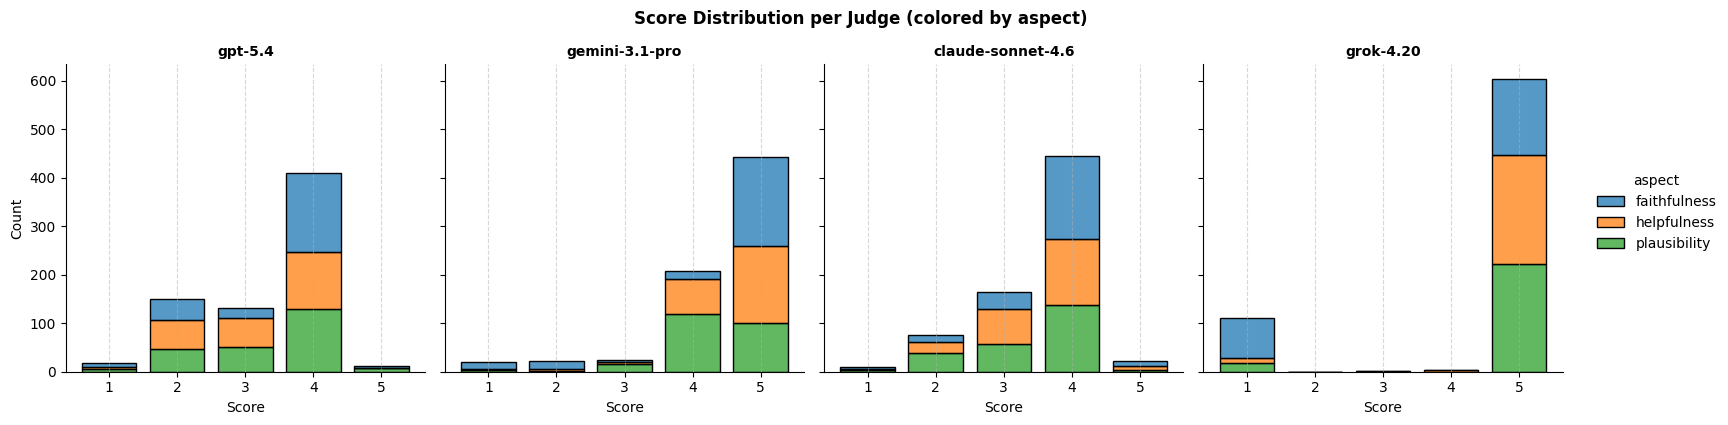

In [ ]:
# --- 1. Calibration table code ---
calib = (
    DF.dropna(subset=["score"])
    .groupby(["judge_short", "aspect"])["score"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        floor_share=lambda s: (s == 1).mean(),
        ceiling_share=lambda s: (s == 5).mean(),
    )
    .round(3)
    .reset_index()
)

print("Judge calibration")
print(calib.to_string(index=False))
save_csv(calib, "33_judge_calibration")

md("### 3.3 Judge calibration\n")
md(calib.to_markdown(index=False))
md("")

# --- 2. Plotting Code (Stacked) ---
# Create the facet grid with stacked bar charts
g = sns.displot(
    data=DF.dropna(subset=["score"]),
    x="score",
    hue="aspect",
    col="judge_short",
    multiple="stack",  # Changed from "dodge" to "stack"
    discrete=True,     # Forces bars to center on integers (1, 2, 3, 4, 5)
    shrink=0.8,        # Slight gap between score groups
    height=4,          # Height of each subplot
    aspect=1           # Width-to-height ratio of each subplot
)

# Styling
g.fig.suptitle("Score Distribution per Judge (colored by aspect)", y=1.05, weight="bold")
g.set_titles(col_template="{col_name}", weight="bold", size=10)
g.set_axis_labels("Score", "Count")

# Add light vertical grid lines
for ax in g.axes.flat:
    ax.grid(axis='x', linestyle='--', alpha=0.5)

# Save and show
plt.savefig(OUT_DIR / "33_judge_calibration_chart_stacked.svg", bbox_inches="tight")
plt.show()

### 3.4 Self-enhancement bias check

**What it tests:** Narratives are generated by a Gemini model `google/gemini-3-flash-preview`. Does the Gemini-family judge (`gemini-3.1-pro-preview`) score these narratives higher than the other three judges do?

**How:** For each (experiment, instance, persona, aspect):
- Gemini vs mean of others (the original — keep it for transparency, with a note about the Grok confound)
- Gemini vs median of others (robust version)
- Gemini vs Claude and Gemini vs GPT separately (cleanest)

In [19]:
GEMINI_JUDGE = "google/gemini-3.1-pro-preview"
OTHER_JUDGES = [j for j in JUDGE_MODELS if j != GEMINI_JUDGE]
REFERENCE_JUDGES = ["openai/gpt-5.4", "anthropic/claude-sonnet-4.6", "x-ai/grok-4.20"]

bias_rows = []

for aspect in JUDGE_ASPECTS:
    sub = wide[wide["aspect"] == aspect].dropna(subset=JUDGE_MODELS)
    if len(sub) < 5:
        continue
    gemini = sub[GEMINI_JUDGE].values

    # Test 1: Gemini vs MEAN of the other three (original — kept for transparency).
    # Caveat: Grok's bimodal 1/5 distribution pulls the mean around and may
    # inflate or deflate apparent bias.
    others_mean = sub[OTHER_JUDGES].mean(axis=1).values
    try:
        stat_mean, p_mean = stats.wilcoxon(gemini, others_mean, zero_method="wilcox")
    except ValueError:
        stat_mean, p_mean = (np.nan, np.nan)
    bias_rows.append({
        "aspect": aspect,
        "comparison": "Gemini vs mean of GPT/Claude/Grok",
        "n": len(sub),
        "mean_gemini": round(gemini.mean(), 3),
        "mean_reference": round(others_mean.mean(), 3),
        "mean_diff": round((gemini - others_mean).mean(), 3),
        "wilcoxon_stat": round(stat_mean, 1) if not np.isnan(stat_mean) else np.nan,
        "p_value": round(p_mean, 4) if not np.isnan(p_mean) else np.nan,
    })

    # Test 2: Gemini vs MEDIAN of the other three.
    # Robust to Grok's bimodality — Grok's score is one vote among three.
    others_median = sub[OTHER_JUDGES].median(axis=1).values
    try:
        stat_med, p_med = stats.wilcoxon(gemini, others_median, zero_method="wilcox")
    except ValueError:
        stat_med, p_med = (np.nan, np.nan)
    bias_rows.append({
        "aspect": aspect,
        "comparison": "Gemini vs median of GPT/Claude/Grok",
        "n": len(sub),
        "mean_gemini": round(gemini.mean(), 3),
        "mean_reference": round(others_median.mean(), 3),
        "mean_diff": round((gemini - others_median).mean(), 3),
        "wilcoxon_stat": round(stat_med, 1) if not np.isnan(stat_med) else np.nan,
        "p_value": round(p_med, 4) if not np.isnan(p_med) else np.nan,
    })

    # Test 3 & 4: Gemini vs other judge separately.
    # Strongest test of self-enhancement: does Gemini score higher than the
    # two judges most aligned with human ratings (GPT and Claude) (Section 2.1)?
    for ref_judge in REFERENCE_JUDGES:
        ref_scores = sub[ref_judge].values
        try:
            stat_pair, p_pair = stats.wilcoxon(gemini, ref_scores, zero_method="wilcox")
        except ValueError:
            stat_pair, p_pair = (np.nan, np.nan)
        bias_rows.append({
            "aspect": aspect,
            "comparison": f"Gemini vs {JUDGE_SHORT[ref_judge]}",
            "n": len(sub),
            "mean_gemini": round(gemini.mean(), 3),
            "mean_reference": round(ref_scores.mean(), 3),
            "mean_diff": round((gemini - ref_scores).mean(), 3),
            "wilcoxon_stat": round(stat_pair, 1) if not np.isnan(stat_pair) else np.nan,
            "p_value": round(p_pair, 4) if not np.isnan(p_pair) else np.nan,
        })

bias_df = pd.DataFrame(bias_rows)

# Apply Holm
p_vals = bias_df["p_value"].tolist()
p_holm = holm_correct(p_vals)
bias_df["p_holm"] = [round(p, 6) if not np.isnan(p) else np.nan for p in p_holm]
bias_df["sig_holm"] = bias_df["p_holm"] < 0.05

print("Self-enhancement bias check: Gemini vs reference judges (multiple specifications)")
print(bias_df.to_string(index=False))
save_csv(bias_df, "34_self_enhancement_bias")

md("### 3.4 Self-enhancement bias (Gemini vs reference judges)\n")
md("Four specifications per aspect to triangulate the result:\n")
md("- vs mean of other three (original; sensitive to Grok's bimodal scoring)\n")
md("- vs median of other three (robust to Grok)\n")
md("- vs GPT-5.4 alone (well-calibrated reference)\n")
md("- vs Claude-Sonnet-4.6 alone (well-calibrated reference)\n")
md("- vs Grok-4.20 alone (included for completeness; note bimodal scoring pattern)\n")
md("If all five converge on the same direction, the self-enhancement-direction effect is robust.\n")
md(bias_df.to_markdown(index=False))
md("")

Self-enhancement bias check: Gemini vs reference judges (multiple specifications)
      aspect                          comparison   n  mean_gemini  mean_reference  mean_diff  wilcoxon_stat  p_value  p_holm  sig_holm
faithfulness   Gemini vs mean of GPT/Claude/Grok 240        4.410           3.601      0.810         3093.0      0.0     0.0      True
faithfulness Gemini vs median of GPT/Claude/Grok 240        4.410           3.619      0.792         2549.5      0.0     0.0      True
faithfulness                   Gemini vs gpt-5.4 240        4.410           3.473      0.938         2081.0      0.0     0.0      True
faithfulness         Gemini vs claude-sonnet-4.6 240        4.410           3.721      0.690         3903.0      0.0     0.0      True
faithfulness                 Gemini vs grok-4.20 240        4.410           3.608      0.802          633.5      0.0     0.0      True
 helpfulness   Gemini vs mean of GPT/Claude/Grok 240        4.596           3.836      0.760          111.0 

## Section 4 - (§4.3.3) Persona effects

### 4.1 Persona effect within judge

**What it tests:** Holding the judge model fixed, does persona assignment shift scores?

**How:** Friedman test paired across personas for each (experiment, judge, aspect). Same instance is rated under each persona, so the data is paired by instance.

Reported: Friedman χ², p-value, and Kendall's W (effect size). Post-hoc Wilcoxon on persona pairs only when Friedman p < 0.05.

In [20]:
# --- STEP 1: Run all 48 Friedman tests first ---
friedman_rows = []
for (exp, judge, aspect), sub in DF.dropna(subset=["score"]).groupby(["experiment", "judge", "aspect"]):
    pivot = sub.pivot_table(index="instance", columns="persona", values="score")
    pivot = pivot.dropna(axis=0)
    
    if pivot.shape[1] < 2 or pivot.shape[0] < 3:
        continue
        
    arr = pivot.to_numpy()
    try:
        chi2, p = stats.friedmanchisquare(*[arr[:, c] for c in range(arr.shape[1])])
    except ValueError:
        chi2, p = (np.nan, np.nan)
        
    W = kendalls_w(arr) if not np.isnan(chi2) else np.nan
    
    friedman_rows.append({
        "experiment": exp,
        "judge": JUDGE_SHORT.get(judge, judge),
        "aspect": aspect,
        "n_instances": pivot.shape[0],
        "n_personas": pivot.shape[1],
        "friedman_chi2": round(chi2, 3) if not np.isnan(chi2) else np.nan,
        "p_value": round(p, 4) if not np.isnan(p) else np.nan,
        "kendalls_w": round(W, 3) if not np.isnan(W) else np.nan,
        # Store the pivot table temporarily so we don't have to rebuild it for post-hoc tests
        "_pivot_data": pivot 
    })

friedman_df = pd.DataFrame(friedman_rows)

# --- STEP 2: Apply Holm correction to the 48 Friedman tests ---
p_vals_friedman = friedman_df["p_value"].tolist()
p_holm_friedman = holm_correct(p_vals_friedman)

friedman_df["sig_uncorrected"] = friedman_df["p_value"] < 0.05
friedman_df["p_holm"] = [round(p, 4) if not np.isnan(p) else np.nan for p in p_holm_friedman]
friedman_df["sig_holm"] = [(not np.isnan(p)) and p < 0.05 for p in p_holm_friedman]

# --- STEP 3: Run Post-hoc Wilcoxon ONLY if the Holm-corrected Friedman p-value < 0.05 ---
wilcoxon_rows = []

for _, row in friedman_df.iterrows():
    # THE TRUE GATEKEEPER: Check the corrected p-value
    if row["sig_holm"]: 
        exp = row["experiment"]
        judge = row["judge"]
        aspect = row["aspect"]
        pivot = row["_pivot_data"]
        
        family_rows = []
        for pa, pb in combinations(pivot.columns, 2):
            try:
                stat, p_w = stats.wilcoxon(pivot[pa], pivot[pb], zero_method="wilcox")
            except ValueError:
                stat, p_w = (np.nan, np.nan)
            family_rows.append({
                "experiment": exp,
                "judge": judge,
                "aspect": aspect,
                "persona_a": pa,
                "persona_b": pb,
                "wilcoxon_stat": round(stat, 3) if not np.isnan(stat) else np.nan,
                "p_value": round(p_w, 4) if not np.isnan(p_w) else np.nan,
            })
            
        # Holm correction within this post-hoc family
        adj_p = holm_correct([r["p_value"] for r in family_rows])
        for r, ap in zip(family_rows, adj_p):
            r["p_holm"] = round(ap, 4) if not np.isnan(ap) else np.nan
            r["sig_holm"] = (not np.isnan(ap)) and ap < 0.05
            wilcoxon_rows.append(r)

# Clean up the temporary column used to store the pivot data
friedman_df = friedman_df.drop(columns=["_pivot_data"])
wilcoxon_df = pd.DataFrame(wilcoxon_rows)

# --- Output Results ---
print("Friedman test results (persona effect within judge)")
print(f"Total Friedman tests: {len(friedman_df)}")
print(f"Significant WITHOUT Holm: {friedman_df['sig_uncorrected'].sum()}")
print(f"Significant WITH Holm: {friedman_df['sig_holm'].sum()}\n")

print(friedman_df.to_string(index=False))
save_csv(friedman_df, "41_persona_friedman")
if len(wilcoxon_df):
    print(f"\nPost-hoc Wilcoxon with Holm correction within each (exp, judge, aspect) family")
    print(f"  Total post-hoc tests: {len(wilcoxon_df)}")
    print(f"  Significant after Holm: {int(wilcoxon_df['sig_holm'].sum())}")
    print()
    sig_only = wilcoxon_df[wilcoxon_df["sig_holm"]]
    if len(sig_only):
        print("Pairs surviving Holm correction:")
        print(sig_only.to_string(index=False))
    else:
        print("No pairs survive Holm correction.")
    save_csv(wilcoxon_df, "41_persona_wilcoxon_posthoc")
else:
    print("\nNo significant Friedman results after Holm correction, so ZERO post-hoc Wilcoxon tests were performed.")

md("## Section 4 - (§4.3.3) Persona effects\n")
md("### 4.1 Persona effect within judge — Friedman\n")
md(friedman_df.to_markdown(index=False))
md("")
if len(wilcoxon_df):
    md("#### Post-hoc Wilcoxon (Holm-corrected within each exp/judge/aspect family)\n")
    md(f"Total post-hoc tests: {len(wilcoxon_df)} — surviving Holm correction: {int(wilcoxon_df['sig_holm'].sum())}\n")
    md(wilcoxon_df.to_markdown(index=False))
    md("")

c:\Users\Lande\school\Thesis\venv\Lib\site-packages\scipy\stats\_stats_py.py:8593: RuntimeWarning: invalid value encountered in scalar divide
  statistic = (12.0 / (k*n*(k+1)) * ssbn - 3*n*(k+1)) / c
c:\Users\Lande\school\Thesis\venv\Lib\site-packages\scipy\stats\_stats_py.py:8593: RuntimeWarning: invalid value encountered in scalar divide
  statistic = (12.0 / (k*n*(k+1)) * ssbn - 3*n*(k+1)) / c
c:\Users\Lande\school\Thesis\venv\Lib\site-packages\scipy\stats\_stats_py.py:8593: RuntimeWarning: invalid value encountered in scalar divide
  statistic = (12.0 / (k*n*(k+1)) * ssbn - 3*n*(k+1)) / c
c:\Users\Lande\school\Thesis\venv\Lib\site-packages\scipy\stats\_stats_py.py:8593: RuntimeWarning: invalid value encountered in scalar divide
  statistic = (12.0 / (k*n*(k+1)) * ssbn - 3*n*(k+1)) / c
c:\Users\Lande\school\Thesis\venv\Lib\site-packages\scipy\stats\_stats_py.py:8593: RuntimeWarning: invalid value encountered in scalar divide
  statistic = (12.0 / (k*n*(k+1)) * ssbn - 3*n*(k+1)) / c


Friedman test results (persona effect within judge)
Total Friedman tests: 48
Significant WITHOUT Holm: 20
Significant WITH Holm: 8

      experiment             judge       aspect  n_instances  n_personas  friedman_chi2  p_value  kendalls_w  sig_uncorrected  p_holm  sig_holm
       mexgen_gc claude-sonnet-4.6 faithfulness           10           3          3.000   0.2231       0.150            False  1.0000     False
       mexgen_gc claude-sonnet-4.6  helpfulness           10           3            NaN      NaN         NaN            False     NaN     False
       mexgen_gc claude-sonnet-4.6 plausibility           10           3          6.000   0.0498       0.300             True  1.0000     False
       mexgen_gc    gemini-3.1-pro faithfulness           10           3          5.200   0.0743       0.260            False  1.0000     False
       mexgen_gc    gemini-3.1-pro  helpfulness           10           3            NaN      NaN         NaN            False     NaN     False
    

### 4.1b Persona effect within aggregated judge

In [21]:
# -------------------------------------------------------------------------
# Section 4.1b — Persona effect on aggregated scores (Friedman)
# -------------------------------------------------------------------------
# Mirror of Section 4.1, but operating on AGG_DF (majority-voted aggregate
# across all four judges) rather than individual judge scores.
# Tests whether persona assignment produces systematic differences in the
# final aggregate score used for all downstream conclusions.
# Holm correction applied across all (experiment, aspect) tests as one family.

agg_friedman_rows = []
agg_wilcoxon_rows = []

for (exp, aspect), sub in (
    AGG_DF.dropna(subset=["aggregate_score"])
    .groupby(["experiment", "aspect"])
):
    pivot = sub.pivot_table(
        index="instance",
        columns="persona",
        values="aggregate_score"
    ).dropna(axis=0)

    if pivot.shape[1] < 2 or pivot.shape[0] < 3:
        continue

    arr = pivot.to_numpy()
    try:
        chi2, p = stats.friedmanchisquare(*[arr[:, c] for c in range(arr.shape[1])])
    except ValueError:
        chi2, p = (np.nan, np.nan)

    W = kendalls_w(arr) if not np.isnan(chi2) else np.nan

    agg_friedman_rows.append({
        "experiment": exp,
        "aspect": aspect,
        "n_instances": pivot.shape[0],
        "n_personas": pivot.shape[1],
        "friedman_chi2": round(chi2, 3) if not np.isnan(chi2) else np.nan,
        "p_value": round(p, 4) if not np.isnan(p) else np.nan,
        "kendalls_w": round(W, 3) if not np.isnan(W) else np.nan,
    })

agg_friedman_df = pd.DataFrame(agg_friedman_rows)

# Holm correction across all (experiment, aspect) tests as one family
p_vals = agg_friedman_df["p_value"].tolist()
p_holm = holm_correct(p_vals)
agg_friedman_df["p_holm"] = [round(p, 4) if not np.isnan(p) else np.nan for p in p_holm]
agg_friedman_df["sig_holm"] = [(not np.isnan(p)) and p < 0.05 for p in p_holm]

# Post-hoc Wilcoxon for any Friedman that survives Holm correction
for _, row in agg_friedman_df[agg_friedman_df["sig_holm"]].iterrows():
    exp, aspect = row["experiment"], row["aspect"]
    sub = (
        AGG_DF.dropna(subset=["aggregate_score"])
        [(AGG_DF["experiment"] == exp) & (AGG_DF["aspect"] == aspect)]
    )
    pivot = sub.pivot_table(
        index="instance",
        columns="persona",
        values="aggregate_score"
    ).dropna(axis=0)

    family_rows = []
    for pa, pb in combinations(pivot.columns, 2):
        try:
            stat, p_w = stats.wilcoxon(pivot[pa], pivot[pb], zero_method="wilcox")
        except ValueError:
            stat, p_w = (np.nan, np.nan)
        family_rows.append({
            "experiment": exp,
            "aspect": aspect,
            "persona_a": pa,
            "persona_b": pb,
            "wilcoxon_stat": round(stat, 3) if not np.isnan(stat) else np.nan,
            "p_value": round(p_w, 4) if not np.isnan(p_w) else np.nan,
        })

    # Holm correction within this (experiment, aspect) family
    adj_p = holm_correct([r["p_value"] for r in family_rows])
    for r, ap in zip(family_rows, adj_p):
        r["p_holm"] = round(ap, 4) if not np.isnan(ap) else np.nan
        r["sig_holm"] = (not np.isnan(ap)) and ap < 0.05
        agg_wilcoxon_rows.append(r)

agg_wilcoxon_df = pd.DataFrame(agg_wilcoxon_rows)

print("Persona effect on aggregated scores — Friedman (Holm-corrected across all exp/aspect families)")
print(agg_friedman_df.to_string(index=False))
save_csv(agg_friedman_df, "41_agg_persona_friedman")

if len(agg_wilcoxon_df):
    print(f"\nPost-hoc Wilcoxon with Holm correction within each (exp, aspect) family")
    print(f"  Total post-hoc tests: {len(agg_wilcoxon_df)}")
    print(f"  Significant after Holm: {int(agg_wilcoxon_df['sig_holm'].sum())}")
    print()
    sig_only = agg_wilcoxon_df[agg_wilcoxon_df["sig_holm"]]
    if len(sig_only):
        print("Pairs surviving Holm correction:")
        print(sig_only.to_string(index=False))
    else:
        print("No pairs survive Holm correction.")
    save_csv(agg_wilcoxon_df, "41_agg_persona_wilcoxon_posthoc")
else:
    print("\nNo Friedman results survive Holm correction — no post-hoc Wilcoxon performed.")

md("### 4.1b — Persona effect on aggregated scores (Friedman + Holm)\n")
md("Mirror of Section 4.1 operating on the majority-voted aggregate across all four judges. ")
md("Tests whether persona assignment systematically shifts the final aggregate score. ")
md("Holm correction applied across all 12 (experiment, aspect) tests as one family.\n")
md(agg_friedman_df.to_markdown(index=False))
md("")
if len(agg_wilcoxon_df):
    md("#### Post-hoc Wilcoxon (Holm-corrected within each exp/aspect family)\n")
    md(f"Total post-hoc tests: {len(agg_wilcoxon_df)} — surviving Holm correction: {int(agg_wilcoxon_df['sig_holm'].sum())}\n")
    md(agg_wilcoxon_df.to_markdown(index=False))
    md("")

Persona effect on aggregated scores — Friedman (Holm-corrected across all exp/aspect families)
      experiment       aspect  n_instances  n_personas  friedman_chi2  p_value  kendalls_w  p_holm  sig_holm
       mexgen_gc faithfulness           10           3          4.467   0.1072       0.223  0.6432     False
       mexgen_gc  helpfulness           10           3          1.077   0.5836       0.054  1.0000     False
       mexgen_gc plausibility           10           3          0.636   0.7275       0.032  1.0000     False
   mexgen_stroke faithfulness           10           5         14.917   0.0049       0.373  0.0392      True
   mexgen_stroke  helpfulness           10           5         24.662   0.0001       0.617  0.0011      True
   mexgen_stroke plausibility           10           5         20.219   0.0005       0.505  0.0045      True
    tokenshap_gc faithfulness           20           3          3.444   0.1787       0.086  0.8935     False
    tokenshap_gc  helpfulness    

### 4.2 Elaborate vs sparse persona in Stroke

**What it tests:** Does adding more detail to a persona description (Dong et al. persona-sparsity claim) actually shift scores?

**How:** Wilcoxon signed-rank, paired by (experiment, instance, judge, aspect). Persona pairs:
- patient vs elaborate_patient
- doctor vs elaborate_doctor

Only run on the Stroke experiments (German Credit only has expert/client/officer).

In [22]:
# Identify which persona names exist in the Stroke logs and which to pair
stroke_personas = sorted(DF[DF["use_case"] == "Stroke"]["persona"].dropna().unique())
print(f"Stroke personas found: {stroke_personas}")

# Auto-detect base/elaborate pairs. Try both naming conventions:
#   <base>_elaborate  (e.g. doctor_elaborate, patient_elaborate)
#   elaborate_<base>  (e.g. elaborate_doctor, elaborate_patient)
PAIRS = []
for p in stroke_personas:
    if p.endswith("_elaborate"):
        base = p[: -len("_elaborate")]
        if base in stroke_personas:
            PAIRS.append((base, p))
    elif p.startswith("elaborate_"):
        base = p[len("elaborate_") :]
        if base in stroke_personas:
            PAIRS.append((base, p))

# Deduplicate (a persona might match both patterns)
PAIRS = list(dict.fromkeys(PAIRS))
print(f"Auto-detected pairs (base, elaborate): {PAIRS}")

elab_rows = []
for base, elaborate in PAIRS:
    for aspect in JUDGE_ASPECTS:
        sub = DF[(DF["use_case"] == "Stroke") & (DF["aspect"] == aspect)].dropna(subset=["score"])
        pivot = sub.pivot_table(
            index=["experiment", "instance", "judge"],
            columns="persona",
            values="score",
        )
        if base not in pivot.columns or elaborate not in pivot.columns:
            continue
        pair_df = pivot[[base, elaborate]].dropna()
        if len(pair_df) < 5:
            continue
        try:
            stat, p = stats.wilcoxon(pair_df[base], pair_df[elaborate], zero_method="wilcox")
        except ValueError:
            stat, p = (np.nan, np.nan)
        diff = (pair_df[elaborate] - pair_df[base]).mean()

        nz = (pair_df[elaborate] - pair_df[base])
        nz = nz[nz != 0]
        if len(nz) > 0:
            ranks = stats.rankdata(np.abs(nz))
            pos = ranks[nz > 0].sum()
            neg = ranks[nz < 0].sum()
            r_rb = (pos - neg) / ranks.sum()
        else:
            r_rb = np.nan

        elab_rows.append({
            "base_persona": base,
            "elaborate_persona": elaborate,
            "aspect": aspect,
            "n_pairs": len(pair_df),
            "mean_base": round(pair_df[base].mean(), 3),
            "mean_elaborate": round(pair_df[elaborate].mean(), 3),
            "mean_diff_elab_minus_base": round(diff, 3),
            "wilcoxon_stat": round(stat, 1) if not np.isnan(stat) else np.nan,
            "p_value": round(p, 4) if not np.isnan(p) else np.nan,
            "rank_biserial_r": round(r_rb, 3) if not np.isnan(r_rb) else np.nan,
        })

elab_df = pd.DataFrame(elab_rows)
if len(elab_df):
    # Holm-correct within each (base_persona, aspect) family across the experiments;
    # in this design every (base, aspect) row corresponds to one comparison so we
    # apply Holm across all rows of the table to keep familywise error in check.
    elab_df["p_holm"] = holm_correct(list(elab_df["p_value"]))
    elab_df["p_holm"] = elab_df["p_holm"].round(4)
    elab_df["sig_holm"] = elab_df["p_holm"] < 0.05
    print("Elaborate vs sparse persona (Stroke) — paired Wilcoxon")
    print(elab_df.to_string(index=False))
    save_csv(elab_df, "42_elaborate_vs_sparse")

    md("### 4.2 Elaborate vs sparse persona (Stroke)\n")
    md(f"Holm correction applied across all {len(elab_df)} comparisons. Surviving: {int(elab_df['sig_holm'].sum())}\n")
    md(elab_df.to_markdown(index=False))
    md("")
else:
    print("No persona pairs detected. Adjust PAIRS manually if persona names differ.")
    print(f"Available stroke personas: {stroke_personas}")

Stroke personas found: ['doctor', 'doctor_elaborate', 'expert_judge', 'patient', 'patient_elaborate']
Auto-detected pairs (base, elaborate): [('doctor', 'doctor_elaborate'), ('patient', 'patient_elaborate')]
Elaborate vs sparse persona (Stroke) — paired Wilcoxon
base_persona elaborate_persona       aspect  n_pairs  mean_base  mean_elaborate  mean_diff_elab_minus_base  wilcoxon_stat  p_value  rank_biserial_r  p_holm  sig_holm
      doctor  doctor_elaborate faithfulness      120      4.008           3.679                     -0.329            7.0   0.0002           -0.933  0.0006      True
      doctor  doctor_elaborate  helpfulness      120      4.167           3.742                     -0.425            0.0   0.0000           -1.000  0.0000      True
      doctor  doctor_elaborate plausibility      120      4.025           3.725                     -0.300           39.0   0.0000           -0.900  0.0000      True
     patient patient_elaborate faithfulness      120      3.879          

### 4.3 Judge effect vs persona effect — variance comparison (Q3)

**What it tests:** Is the variability across judges (with everything else held fixed) larger 
than the variability across personas (with everything else held fixed)?

**How:** For each (experiment, instance, aspect):
- compute the standard deviation across judges, with persona varying within
- compute the standard deviation across personas, with judge varying within

Pool both into a paired sample (one pair per cell) and run paired Wilcoxon. 
Positive direction means judge variance > persona variance.

In [23]:
# Strategy: build per-(exp, instance, aspect) variance for judges and personas separately.
#
# Within-judge SD (persona effect): for each (exp, inst, aspect, judge), compute SD across personas.
#   Then average across judges to get one "persona-induced SD" per (exp, inst, aspect).
# Within-persona SD (judge effect): for each (exp, inst, aspect, persona), compute SD across judges.
#   Then average across personas to get one "judge-induced SD" per (exp, inst, aspect).

tidy = DF.dropna(subset=["score"])

persona_induced = (
    tidy.groupby(["experiment", "instance", "aspect", "judge"])["score"]
    .std(ddof=1)
    .groupby(["experiment", "instance", "aspect"])
    .mean()
    .rename("persona_induced_sd")
)
judge_induced = (
    tidy.groupby(["experiment", "instance", "aspect", "persona"])["score"]
    .std(ddof=1)
    .groupby(["experiment", "instance", "aspect"])
    .mean()
    .rename("judge_induced_sd")
)

pair = pd.concat([persona_induced, judge_induced], axis=1).dropna()

var_rows = []
for aspect in JUDGE_ASPECTS:
    sub = pair.xs(aspect, level="aspect")
    if len(sub) < 3:
        continue
    diff = sub["judge_induced_sd"] - sub["persona_induced_sd"]
    try:
        stat, p = stats.wilcoxon(sub["judge_induced_sd"], sub["persona_induced_sd"], zero_method="wilcox")
    except ValueError:
        stat, p = (np.nan, np.nan)
    # Effect size: rank-biserial correlation
    nz = diff[diff != 0]
    if len(nz) > 0:
        ranks = stats.rankdata(np.abs(nz))
        pos = ranks[nz > 0].sum()
        neg = ranks[nz < 0].sum()
        r_rb = (pos - neg) / ranks.sum() if ranks.sum() > 0 else np.nan
    else:
        r_rb = np.nan
    var_rows.append({
        "aspect": aspect,
        "n_cells": len(sub),
        "mean_persona_sd": round(sub["persona_induced_sd"].mean(), 3),
        "mean_judge_sd": round(sub["judge_induced_sd"].mean(), 3),
        "mean_diff_judge_minus_persona": round(diff.mean(), 3),
        "wilcoxon_stat": round(stat, 1) if not np.isnan(stat) else np.nan,
        "p_value": round(p, 6) if not np.isnan(p) else np.nan,
        "rank_biserial_r": round(r_rb, 3) if not np.isnan(r_rb) else np.nan,
    })
var_df = pd.DataFrame(var_rows)

p_vals = var_df["p_value"].tolist()
p_holm = holm_correct(p_vals)
var_df["p_holm"] = [round(p, 6) if not np.isnan(p) else np.nan for p in p_holm]
var_df["sig_holm"] = [(not np.isnan(p)) and p < 0.05 for p in p_holm]

print("Judge-induced SD vs persona-induced SD (paired Wilcoxon)")
print(var_df.to_string(index=False))
save_csv(var_df, "43_judge_vs_persona_variance")

md("### 4.3 Judge effect vs persona effect — variance comparison\n")
md("Per-(experiment, instance, aspect) cell, comparing the SD induced by varying judge against the SD induced by varying persona.\n")
md(var_df.to_markdown(index=False))
md("")

Judge-induced SD vs persona-induced SD (paired Wilcoxon)
      aspect  n_cells  mean_persona_sd  mean_judge_sd  mean_diff_judge_minus_persona  wilcoxon_stat  p_value  rank_biserial_r  p_holm  sig_holm
faithfulness       60            0.432          1.001                          0.569            4.0      0.0            0.996     0.0      True
 helpfulness       60            0.213          0.899                          0.686            0.0      0.0            1.000     0.0      True
plausibility       60            0.218          0.822                          0.604            0.0      0.0            1.000     0.0      True
  -> saved analysis_outputs\csv\43_judge_vs_persona_variance.csv


## Section 5 - (§4.3.4) Evaluation metrics

### 5.1 Faithfulness ↔ Helpfulness/Plausibility correlation per judge

**What it tests:** Within a single judge model, do narratives that score higher on faithfulness also score higher on helpfulness/plausibility — or do they trade off?

**How:** Spearman correlation across all (experiment, instance, persona) units, per judge.
Negative or near-zero correlation supports the Feustel et al. claim that fluency and factual accuracy can diverge.

In [24]:
# Pivot to one row per (experiment, instance, persona, judge), columns = aspects
wide_aspects = DF.pivot_table(
    index=["experiment", "instance", "persona", "judge"],
    columns="aspect",
    values="score",
).reset_index()

# Pivot the aggregate data: one row per (experiment, instance, persona), columns = aspects
agg_wide_aspects = AGG_DF.dropna(subset=["aggregate_score"]).pivot_table(
    index=["experiment", "instance", "persona"],
    columns="aspect",
    values="aggregate_score",
).reset_index()

fhp_rows = []

# --- 1. Compute correlations for the Aggregate (Majority Vote) ---
sub_agg = agg_wide_aspects.dropna(subset=JUDGE_ASPECTS)
if len(sub_agg) >= 3:
    rho_fh, p_fh = stats.spearmanr(sub_agg["faithfulness"], sub_agg["helpfulness"])
    rho_fp, p_fp = stats.spearmanr(sub_agg["faithfulness"], sub_agg["plausibility"])
    rho_hp, p_hp = stats.spearmanr(sub_agg["helpfulness"], sub_agg["plausibility"])
    fhp_rows.append({
        "judge": "Aggregate (Majority Vote)",
        "n": len(sub_agg),
        "rho_faith_help": round(rho_fh, 3),
        "p_faith_help": round(p_fh, 4),
        "rho_faith_plaus": round(rho_fp, 3),
        "p_faith_plaus": round(p_fp, 4),
        "rho_help_plaus": round(rho_hp, 3),
        "p_help_plaus": round(p_hp, 4),
    })

# --- 2. Compute correlations per individual judge ---
for judge in JUDGE_MODELS:
    sub = wide_aspects[wide_aspects["judge"] == judge].dropna(subset=JUDGE_ASPECTS)
    if len(sub) < 3:
        continue
    rho_fh, p_fh = stats.spearmanr(sub["faithfulness"], sub["helpfulness"])
    rho_fp, p_fp = stats.spearmanr(sub["faithfulness"], sub["plausibility"])
    rho_hp, p_hp = stats.spearmanr(sub["helpfulness"], sub["plausibility"])
    fhp_rows.append({
        "judge": JUDGE_SHORT[judge],
        "n": len(sub),
        "rho_faith_help": round(rho_fh, 3),
        "p_faith_help": round(p_fh, 4),
        "rho_faith_plaus": round(rho_fp, 3),
        "p_faith_plaus": round(p_fp, 4),
        "rho_help_plaus": round(rho_hp, 3),
        "p_help_plaus": round(p_hp, 4),
    })

fhp_df = pd.DataFrame(fhp_rows)

# --- 3. Apply Holm correction across all 15 tests ---
p_vals = []
for _, row in fhp_df.iterrows():
    p_vals += [row["p_faith_help"], row["p_faith_plaus"], row["p_help_plaus"]]

p_holm = holm_correct(p_vals)

# Split corrected p-values back into columns
fhp_df["p_holm_faith_help"]  = [round(p_holm[i*3],   6) for i in range(len(fhp_df))]
fhp_df["p_holm_faith_plaus"] = [round(p_holm[i*3+1], 6) for i in range(len(fhp_df))]
fhp_df["p_holm_help_plaus"]  = [round(p_holm[i*3+2], 6) for i in range(len(fhp_df))]

fhp_df["sig_holm_faith_help"]  = fhp_df["p_holm_faith_help"]  < 0.05
fhp_df["sig_holm_faith_plaus"] = fhp_df["p_holm_faith_plaus"] < 0.05
fhp_df["sig_holm_help_plaus"]  = fhp_df["p_holm_help_plaus"]  < 0.05

print("Spearman correlations between aspects, per judge (and aggregate)")
print(fhp_df.to_string(index=False))
save_csv(fhp_df, "51_aspect_correlations")

md("## Section 5 - (§4.3.4) Evaluation metrics\n")
md("### 5.1 Aspect correlations per judge (Spearman)\n")
md(fhp_df.to_markdown(index=False))
md("")

Spearman correlations between aspects, per judge (and aggregate)
                    judge   n  rho_faith_help  p_faith_help  rho_faith_plaus  p_faith_plaus  rho_help_plaus  p_help_plaus  p_holm_faith_help  p_holm_faith_plaus  p_holm_help_plaus  sig_holm_faith_help  sig_holm_faith_plaus  sig_holm_help_plaus
Aggregate (Majority Vote) 240           0.227        0.0004            0.315         0.0000           0.562           0.0             0.0012              0.0000                0.0                 True                  True                 True
                  gpt-5.4 240           0.266        0.0000            0.271         0.0000           0.820           0.0             0.0000              0.0000                0.0                 True                  True                 True
           gemini-3.1-pro 240           0.217        0.0007            0.214         0.0008           0.611           0.0             0.0014              0.0014                0.0                 True   

### 5.2 Attribution-distribution effect on faithfulness

**What it tests:** Are instances with more concentrated (peaked) attribution distributions rated as more faithful than instances where attribution is spread evenly across many tokens?

**How:** For each instance, load its attribution table and compute a concentration metric (Gini coefficient over absolute attribution values). Correlate (Spearman) with the mean faithfulness score across judges and personas.

In [25]:
def gini(values: np.ndarray) -> float:
    """Gini coefficient over a 1D array of non-negative values. Returns NaN if empty/all zero."""
    v = np.asarray(values, dtype=float)
    v = np.abs(v)
    v = v[~np.isnan(v)]
    if len(v) == 0 or v.sum() == 0:
        return np.nan
    v = np.sort(v)
    n = len(v)
    cum = np.cumsum(v)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

def load_attribution_concentrations(pkl_dir: str | None, method: str) -> dict[int, float]:
    """Return {instance_index: gini_concentration} for every pkl file in the directory.

    TokenSHAP pkls: dict with key 'shapley_values' (a dict of token -> shapley value).
    MExGen pkls: dict with key 'output_dict_words' -> 'attributions' -> 'bert' (list)
                 and parallel 'unit_types' (list of 'w' / 'n'). We keep only 'w' entries
                 so that structural separators (which always score 0) don't artificially
                 inflate the Gini coefficient.
    """
    if not pkl_dir or not os.path.isdir(pkl_dir):
        return {}
    out = {}
    for fname in sorted(os.listdir(pkl_dir)):
        if not fname.endswith(".pkl"):
            continue
        full = os.path.join(pkl_dir, fname)
        try:
            with open(full, "rb") as f:
                obj = pickle.load(f)
        except Exception as e:
            print(f"  ! could not load {full}: {e}")
            continue

        values = None
        if method == "TokenSHAP":
            sv = None
            if isinstance(obj, dict) and "shapley_values" in obj:
                sv = obj["shapley_values"]
            elif hasattr(obj, "shapley_values"):
                sv = obj.shapley_values
            if isinstance(sv, dict):
                values = np.array(list(sv.values()), dtype=float)
        elif method == "MExGen":
            try:
                attrs = obj["output_dict_words"]["attributions"]
                bert = attrs["bert"]
                unit_types = attrs["unit_types"]
                # Keep only word units; structural 'n' units always score 0 and would
                # inflate the Gini coefficient artificially.
                values = np.array(
                    [v for v, ut in zip(bert, unit_types) if ut == "w"],
                    dtype=float,
                )
            except (KeyError, TypeError):
                pass

        if values is None or len(values) == 0:
            continue
        # extract instance index from filename like "..._instance_5.pkl"
        parts = fname.replace(".pkl", "").split("_")
        try:
            inst = int(parts[-1])
        except ValueError:
            continue
        out[inst] = gini(values)
    return out

concentration_rows = []
for exp_name, cfg in EXPERIMENTS.items():
    concs = load_attribution_concentrations(cfg.get("pkl_dir"), cfg["method"])
    if not concs:
        print(f"  {exp_name}: no pkl-derived concentrations available, skipping")
        continue
    print(f"  {exp_name}: {len(concs)} instances with attribution concentration "
          f"(mean Gini = {np.mean(list(concs.values())):.3f})")
    sub = DF[(DF["experiment"] == exp_name) & (DF["aspect"] == "faithfulness")].dropna(subset=["score"])
    inst_mean = sub.groupby("instance")["score"].mean()
    aligned = pd.DataFrame({
        "instance": list(concs.keys()),
        "gini": list(concs.values()),
    })
    aligned = aligned.merge(inst_mean.rename("mean_faithfulness"), on="instance")
    if len(aligned) < 5:
        continue
    rho, p = stats.spearmanr(aligned["gini"], aligned["mean_faithfulness"])
    concentration_rows.append({
        "experiment": exp_name,
        "n_instances": len(aligned),
        "mean_gini": round(aligned["gini"].mean(), 3),
        "spearman_rho": round(rho, 3),
        "p_value": round(p, 4),
    })

concentration_df = pd.DataFrame(concentration_rows)
if len(concentration_df):
    # Apply Holm correction across the experiments
    p_vals = concentration_df["p_value"].tolist()
    p_holm = holm_correct(p_vals)
    concentration_df["p_holm"] = [round(p, 6) if not np.isnan(p) else np.nan for p in p_holm]
    concentration_df["sig_holm"] = concentration_df["p_holm"] < 0.05

    print("\nAttribution concentration (Gini) vs mean faithfulness, per experiment")
    print(concentration_df.to_string(index=False))
    save_csv(concentration_df, "52_attribution_concentration")

    md("### 5.2 Attribution concentration vs faithfulness\n")
    md("Gini coefficient over absolute attribution values per instance, correlated with\n"
       "mean faithfulness across judges and personas.\n")
    md(concentration_df.to_markdown(index=False))
    md("")
else:
    print("\nNo experiments had usable pkl files for this analysis.")

  tokenshap_gc: 20 instances with attribution concentration (mean Gini = 0.522)
  tokenshap_stroke: 20 instances with attribution concentration (mean Gini = 0.449)
  mexgen_gc: 10 instances with attribution concentration (mean Gini = 0.531)
  mexgen_stroke: 10 instances with attribution concentration (mean Gini = 0.569)

Attribution concentration (Gini) vs mean faithfulness, per experiment
      experiment  n_instances  mean_gini  spearman_rho  p_value  p_holm  sig_holm
    tokenshap_gc           20      0.522        -0.465   0.0387  0.1548     False
tokenshap_stroke           20      0.449        -0.250   0.2872  0.8616     False
       mexgen_gc           10      0.531         0.061   0.8671  1.0000     False
   mexgen_stroke           10      0.569         0.219   0.5436  1.0000     False
  -> saved analysis_outputs\csv\52_attribution_concentration.csv


### 5.3 Aspect inflation — faithfulness vs helpfulness/plausibility

**What it tests:** Are helpfulness and plausibility scored systematically higher than faithfulness? 
If so, this supports the Feustel et al. concern that surface fluency can lift the soft metrics 
without requiring actual grounding in the attribution table.

**How:** Paired Wilcoxon on the per-cell score differences, paired by (experiment, instance, persona, judge). 
Pooled across everything to maximise power. Effect size: rank-biserial correlation.

In [26]:
# Pivot to one row per (experiment, instance, persona, judge), columns = aspects
aspect_pivot = DF.dropna(subset=["score"]).pivot_table(
    index=["experiment", "instance", "persona", "judge"],
    columns="aspect",
    values="score",
).dropna()

inflation_rows = []
for compare_aspect in ["helpfulness", "plausibility"]:
    diff = aspect_pivot[compare_aspect] - aspect_pivot["faithfulness"]
    try:
        stat, p = stats.wilcoxon(
            aspect_pivot[compare_aspect],
            aspect_pivot["faithfulness"],
            zero_method="wilcox",
        )
    except ValueError:
        stat, p = (np.nan, np.nan)
    nz = diff[diff != 0]
    if len(nz) > 0:
        ranks = stats.rankdata(np.abs(nz))
        pos = ranks[nz > 0].sum()
        neg = ranks[nz < 0].sum()
        r_rb = (pos - neg) / ranks.sum() if ranks.sum() > 0 else np.nan
    else:
        r_rb = np.nan
    inflation_rows.append({
        "comparison": f"{compare_aspect} vs faithfulness",
        "n_cells": len(aspect_pivot),
        "mean_faithfulness": round(aspect_pivot["faithfulness"].mean(), 3),
        "mean_compared_aspect": round(aspect_pivot[compare_aspect].mean(), 3),
        "mean_diff": round(diff.mean(), 3),
        "wilcoxon_stat": round(stat, 1) if not np.isnan(stat) else np.nan,
        "p_value": round(p, 6) if not np.isnan(p) else np.nan,
        "rank_biserial_r": round(r_rb, 3) if not np.isnan(r_rb) else np.nan,
    })
inflation_df = pd.DataFrame(inflation_rows)

p_vals = inflation_df["p_value"].tolist()
p_holm = holm_correct(p_vals)
inflation_df["p_holm"] = [round(p, 6) if not np.isnan(p) else np.nan for p in p_holm]
inflation_df["sig_holm"] = [(not np.isnan(p)) and p < 0.05 for p in p_holm]

print("Aspect inflation: helpfulness/plausibility vs faithfulness (paired Wilcoxon)")
print(inflation_df.to_string(index=False))
save_csv(inflation_df, "53_aspect_inflation")

# Same comparison broken down per judge (and aggregate) so we can see 
# whether the inflation is universal or driven by specific judges
inflation_perjudge_rows = []

# --- 1. Compute aspect inflation for the Aggregate (Majority Vote) ---
agg_aspect_pivot = AGG_DF.dropna(subset=["aggregate_score"]).pivot_table(
    index=["experiment", "instance", "persona"],
    columns="aspect",
    values="aggregate_score",
).dropna()

for compare_aspect in ["helpfulness", "plausibility"]:
    diff = agg_aspect_pivot[compare_aspect] - agg_aspect_pivot["faithfulness"]
    try:
        stat, p = stats.wilcoxon(agg_aspect_pivot[compare_aspect], agg_aspect_pivot["faithfulness"], zero_method="wilcox")
    except ValueError:
        stat, p = (np.nan, np.nan)
        
    nz = diff[diff != 0]
    if len(nz) > 0:
        ranks = stats.rankdata(np.abs(nz))
        pos = ranks[nz > 0].sum()
        neg = ranks[nz < 0].sum()
        r_rb = (pos - neg) / ranks.sum() if ranks.sum() > 0 else np.nan
    else:
        r_rb = np.nan
        
    inflation_perjudge_rows.append({
        "judge": "Aggregate (Majority Vote)",
        "comparison": f"{compare_aspect} vs faithfulness",
        "n_cells": len(agg_aspect_pivot),
        "mean_diff": round(diff.mean(), 3),
        "wilcoxon_stat": round(stat, 1) if not np.isnan(stat) else np.nan,
        "p_value": round(p, 6) if not np.isnan(p) else np.nan,
        "rank_biserial_r": round(r_rb, 3) if not np.isnan(r_rb) else np.nan,
    })

# --- 2. Compute aspect inflation per individual judge ---
for judge in JUDGE_MODELS:
    sub = aspect_pivot.xs(judge, level="judge")
    if len(sub) < 3:
        continue
    for compare_aspect in ["helpfulness", "plausibility"]:
        diff = sub[compare_aspect] - sub["faithfulness"]
        try:
            stat, p = stats.wilcoxon(sub[compare_aspect], sub["faithfulness"], zero_method="wilcox")
        except ValueError:
            stat, p = (np.nan, np.nan)
            
        nz = diff[diff != 0]
        if len(nz) > 0:
            ranks = stats.rankdata(np.abs(nz))
            pos = ranks[nz > 0].sum()
            neg = ranks[nz < 0].sum()
            r_rb = (pos - neg) / ranks.sum() if ranks.sum() > 0 else np.nan
        else:
            r_rb = np.nan
            
        inflation_perjudge_rows.append({
            "judge": JUDGE_SHORT[judge],
            "comparison": f"{compare_aspect} vs faithfulness",
            "n_cells": len(sub),
            "mean_diff": round(diff.mean(), 3),
            "wilcoxon_stat": round(stat, 1) if not np.isnan(stat) else np.nan,
            "p_value": round(p, 6) if not np.isnan(p) else np.nan,
            "rank_biserial_r": round(r_rb, 3) if not np.isnan(r_rb) else np.nan,
        })

inflation_perjudge_df = pd.DataFrame(inflation_perjudge_rows)

# --- 3. Apply Holm correction across all 10 tests ---
p_vals = inflation_perjudge_df["p_value"].tolist()
p_holm = holm_correct(p_vals)
inflation_perjudge_df["p_holm"] = [round(p, 6) if not np.isnan(p) else np.nan for p in p_holm]
inflation_perjudge_df["sig_holm"] = [(not np.isnan(p)) and p < 0.05 for p in p_holm]

print("\nPer-judge breakdown of aspect inflation")
print(inflation_perjudge_df.to_string(index=False))
save_csv(inflation_perjudge_df, "53_aspect_inflation_per_judge")

md("### 5.3 Aspect inflation — faithfulness vs helpfulness/plausibility\n")
md(inflation_df.to_markdown(index=False))
md("")
md("#### Per-judge breakdown (including aggregate)\n")
md(inflation_perjudge_df.to_markdown(index=False))
md("")

Aspect inflation: helpfulness/plausibility vs faithfulness (paired Wilcoxon)
                  comparison  n_cells  mean_faithfulness  mean_compared_aspect  mean_diff  wilcoxon_stat  p_value  rank_biserial_r  p_holm  sig_holm
 helpfulness vs faithfulness      960              3.803                 4.026      0.223        33114.0   0.0002            0.206  0.0004      True
plausibility vs faithfulness      960              3.803                 3.947      0.144        43338.5   0.0793            0.094  0.0793     False
  -> saved analysis_outputs\csv\53_aspect_inflation.csv

Per-judge breakdown of aspect inflation
                    judge                   comparison  n_cells  mean_diff  wilcoxon_stat  p_value  rank_biserial_r  p_holm  sig_holm
Aggregate (Majority Vote)  helpfulness vs faithfulness      240      0.134         6527.5   0.0981            0.143  0.1962     False
Aggregate (Majority Vote) plausibility vs faithfulness      240     -0.154         6487.5   0.0033           -0

## Section 6 - (§4.4.2) XAI method comparison

### 6.1 Method comparison — TokenSHAP vs MExGen

**What it tests:** Per use case and aspect, do narratives generated from one XAI method receive systematically different scores than the other?

**How:** Paired Wilcoxon signed-rank on aspect scores, matched by `instance` index. The MExGen experiments were run on a balanced 10-instance subset of the TokenSHAP profiles (5 Good + 5 Bad for German Credit; 5 high-risk + 5 low-risk for Stroke), so each MExGen narrative has a TokenSHAP counterpart on the same applicant/patient profile.
Effect size: rank-biserial correlation (matched-pairs analogue of Cliff's delta).

Caveat: n=10 paired observations per use-case-aspect cell. Power is modest, but the within-instance pairing factors out applicant/patient-level variance and is meaningfully more powerful than the unpaired test.

In [27]:
# DESIGN NOTE
# -----------
# The MExGen experiments were run on the SAME applicant/patient profiles as the
# corresponding TokenSHAP experiments — specifically a 10-instance subset balanced
# for label distribution. This means the method comparison is a paired design,
# matched by `instance` index within each use case.
# Therefore: paired Wilcoxon signed-rank test instead of unpaired Mann-Whitney U.
#
# AGGREGATION ACROSS JUDGES
# -------------------------
# We use AGG_DF (the pipeline-computed `aggregate_score`, which is the majority
# vote across the four per-judge final_scores). This is more robust than
# averaging `final_score` across judges because mean is sensitive to outlier
# judges (e.g. Grok's bimodal 1/5 pattern). Across personas (within a single
# narrative-aspect cell), we average the aggregates — averaging here is fine
# because personas are designed to produce different perspectives on the same
# narrative, and a per-narrative summary is what we want.

collapsed = (
    AGG_DF.dropna(subset=["aggregate_score"])
    .groupby(["experiment", "method", "use_case", "instance", "aspect"])["aggregate_score"]
    .mean()
    .reset_index()
    .rename(columns={"aggregate_score": "score"})
)

method_rows = []
for use_case in collapsed["use_case"].unique():
    for aspect in JUDGE_ASPECTS:
        ts = collapsed[(collapsed["use_case"] == use_case) & (collapsed["method"] == "TokenSHAP") & (collapsed["aspect"] == aspect)]
        mx = collapsed[(collapsed["use_case"] == use_case) & (collapsed["method"] == "MExGen") & (collapsed["aspect"] == aspect)]
        if len(ts) < 3 or len(mx) < 3:
            continue

        # Paired test: align on instance index (MExGen is a strict subset of TokenSHAP instances)
        ts_idx = ts.set_index("instance")["score"]
        mx_idx = mx.set_index("instance")["score"]
        common = ts_idx.index.intersection(mx_idx.index)
        n_unmatched = len(mx_idx) - len(common)
        if len(common) < 3:
            continue
        ts_paired = ts_idx.loc[common].values
        mx_paired = mx_idx.loc[common].values
        diff = ts_paired - mx_paired
        try:
            wstat, p_paired = stats.wilcoxon(ts_paired, mx_paired, zero_method="wilcox")
        except ValueError:
            wstat, p_paired = (np.nan, np.nan)
        nz_diff = diff[diff != 0]
        if len(nz_diff) > 0:
            ranks = stats.rankdata(np.abs(nz_diff))
            pos_sum = ranks[nz_diff > 0].sum()
            neg_sum = ranks[nz_diff < 0].sum()
            total = ranks.sum()
            r_rb = (pos_sum - neg_sum) / total if total > 0 else np.nan
        else:
            r_rb = np.nan

        method_rows.append({
            "use_case": use_case,
            "aspect": aspect,
            "n_pairs": len(common),
            "n_unmatched_mexgen": n_unmatched,
            "mean_tokenshap": round(float(np.mean(ts_paired)), 3),
            "mean_mexgen": round(float(np.mean(mx_paired)), 3),
            "mean_diff": round(float(np.mean(diff)), 3),
            "wilcoxon_stat": round(float(wstat), 1) if not np.isnan(wstat) else np.nan,
            "p_value": round(float(p_paired), 4) if not np.isnan(p_paired) else np.nan,
            "rank_biserial_r": round(float(r_rb), 3) if not np.isnan(r_rb) else np.nan,
        })

method_df = pd.DataFrame(method_rows)

# Holm correction across the 6 tests
p_vals = method_df["p_value"].tolist()
p_holm = holm_correct(p_vals)
method_df["p_holm"] = [round(p, 4) if not np.isnan(p) else np.nan for p in p_holm]
method_df["sig_holm"] = [(not np.isnan(p)) and p < 0.05 for p in p_holm]


print("Method comparison (TokenSHAP vs MExGen) — PAIRED Wilcoxon signed-rank")
print("Built on the pipeline\'s aggregate_score (majority vote across judges),")
print("averaged across personas to get one score per (instance, aspect).")
print()
print(method_df.to_string(index=False))
save_csv(method_df, "61_method_comparison_paired")

md("## Section 6 - (§4.4.2) XAI method comparison\n")
md("### 6.1 Method comparison — TokenSHAP vs MExGen (paired Wilcoxon)\n")
md("MExGen was run on the same applicant/patient profiles as TokenSHAP — a balanced 10-instance subset. ")
md("The proper test is therefore a paired Wilcoxon signed-rank, matched by `instance` index. ")
md("Scores per cell are the pipeline\'s `aggregate_score` (majority vote across judges), averaged across personas.\n")
md(method_df.to_markdown(index=False))
md("")

Method comparison (TokenSHAP vs MExGen) — PAIRED Wilcoxon signed-rank
Built on the pipeline's aggregate_score (majority vote across judges),
averaged across personas to get one score per (instance, aspect).

     use_case       aspect  n_pairs  n_unmatched_mexgen  mean_tokenshap  mean_mexgen  mean_diff  wilcoxon_stat  p_value  rank_biserial_r  p_holm  sig_holm
German Credit faithfulness       10                   0           4.233        3.408      0.825            0.0   0.0020            1.000  0.0120      True
German Credit  helpfulness       10                   0           4.517        3.167      1.350            2.0   0.0117            0.911  0.0468      True
German Credit plausibility       10                   0           4.200        2.967      1.233            1.5   0.0059            0.945  0.0295      True
       Stroke faithfulness       10                   0           4.075        3.502      0.573           21.0   0.5566            0.236  0.5566     False
       Stroke  he

## Section 7 - (§4.4.3) Outlier analysis

### 7.1 Outlier instances — narratives that scored exceptionally low

**What it identifies:** Per experiment and aspect, instances whose mean score (across all judges and personas) 
falls below `Q1 − 1.5 × IQR` (Tukey's lower fence) or below `mean − 2 × SD` of that experiment's distribution.

Descriptive only — no formal hypothesis test. Useful for Section 4 if you want to discuss specific bad cases.

In [28]:
outlier_rows = []
# Use AGG_DF (pipeline aggregate_score, majority vote across judges) and
# average across personas to get one summary score per (experiment, instance, aspect).
for (exp, aspect), sub in AGG_DF.dropna(subset=["aggregate_score"]).groupby(["experiment", "aspect"]):
    inst_means = sub.groupby("instance")["aggregate_score"].mean()
    if len(inst_means) < 5:
        continue
    q1, q3 = inst_means.quantile([0.25, 0.75])
    iqr = q3 - q1
    tukey_low = q1 - 1.5 * iqr
    z_low = inst_means.mean() - 2 * inst_means.std(ddof=1)
    for inst, val in inst_means.items():
        if val < tukey_low or val < z_low:
            outlier_rows.append({
                "experiment": exp,
                "aspect": aspect,
                "instance": int(inst),
                "mean_score": round(val, 3),
                "experiment_mean": round(inst_means.mean(), 3),
                "experiment_sd": round(inst_means.std(ddof=1), 3),
                "tukey_low_threshold": round(tukey_low, 3),
                "z2_low_threshold": round(z_low, 3),
                "rule_triggered": (
                    "tukey+z2" if (val < tukey_low and val < z_low)
                    else "tukey" if val < tukey_low
                    else "z2"
                ),
            })
outlier_df = pd.DataFrame(outlier_rows).sort_values(["experiment", "aspect", "instance"])
if len(outlier_df):
    print(f"Outlier instances ({len(outlier_df)} flagged across all experiments x aspects)")
    print(outlier_df.to_string(index=False))
    save_csv(outlier_df, "71_outlier_instances")

    # Also show instances flagged in 2+ aspects within the same experiment
    counts = outlier_df.groupby(["experiment", "instance"]).size().reset_index(name="n_aspects_flagged")
    repeat = counts[counts["n_aspects_flagged"] >= 2].sort_values(["experiment", "n_aspects_flagged"], ascending=[True, False])
    if len(repeat):
        print("\nInstances flagged on 2+ aspects within the same experiment:")
        print(repeat.to_string(index=False))
        save_csv(repeat, "71_outlier_instances_repeat")

    md("## Section 7 - (§4.4.3) Outlier analysis\n")
    md("### 7.1 Outlier instances\n")
    md(outlier_df.to_markdown(index=False))
    md("")
    if len(repeat):
        md("#### Instances flagged on 2+ aspects within the same experiment\n")
        md(repeat.to_markdown(index=False))
        md("")
else:
    print("No instances triggered the outlier rules in any experiment.")
    md("## Section 7 - (§4.4.3) Outlier analysis\n")
    md("### 7.1 Outlier instances\n")
    md("No instances triggered the outlier rules.\n")

Outlier instances (14 flagged across all experiments x aspects)
      experiment       aspect  instance  mean_score  experiment_mean  experiment_sd  tukey_low_threshold  z2_low_threshold rule_triggered
       mexgen_gc faithfulness        95       1.667            3.408          0.861                1.651             1.687             z2
   mexgen_stroke  helpfulness        30       1.300            3.820          1.025                2.600             1.770       tukey+z2
    tokenshap_gc faithfulness       999       3.083            4.221          0.431                3.250             3.359       tukey+z2
    tokenshap_gc  helpfulness        95       4.167            4.550          0.359                4.250             3.832          tukey
    tokenshap_gc  helpfulness       915       3.333            4.550          0.359                4.250             3.832       tukey+z2
    tokenshap_gc plausibility       107       3.333            4.183          0.429                3.438    

## Section 8 - (§6.2) TokenSHAP sampling cap

### 8.1 TokenSHAP effective sampling ratio limit

**What it tests:** TokenSHAP's `max_combinations` cap (default 1000) means longer prompts hit the cap before reaching the requested 0.4 sampling ratio. Does the effective sampling ratio achieved correlate with faithfulness scores?

**How:** For each TokenSHAP instance, compute effective_ratio = combinations_used / 2^n_tokens, then Spearman against mean faithfulness across judges and personas.

Skipped if the pkl directories are not configured or do not record combinations used.

In [29]:
MAX_COMBINATIONS = 1000

def load_tokenshap_token_counts(pkl_dir: str | None) -> dict[int, dict]:
    """Return {instance_index: {n_tokens, sampling_ratio}}."""
    if not pkl_dir or not os.path.isdir(pkl_dir):
        return {}
    out = {}
    for fname in sorted(os.listdir(pkl_dir)):
        if not fname.endswith(".pkl"):
            continue
        full = os.path.join(pkl_dir, fname)
        try:
            with open(full, "rb") as f:
                obj = pickle.load(f)
        except Exception:
            continue

        sv = None
        sr = 0.4  # default
        if isinstance(obj, dict):
            sv = obj.get("shapley_values")
            sr = obj.get("sampling_ratio", 0.4)
        elif hasattr(obj, "shapley_values"):
            sv = obj.shapley_values
            sr = getattr(obj, "sampling_ratio", 0.4)
        if not isinstance(sv, dict):
            continue
        n_tokens = len(sv)
        parts = fname.replace(".pkl", "").split("_")
        try:
            inst = int(parts[-1])
        except ValueError:
            continue
        out[inst] = {"n_tokens": n_tokens, "sampling_ratio": float(sr)}
    return out

def compute_effective_ratio(n_tokens: int, configured_ratio: float, max_combinations: int) -> float:
    """Compute the actual achieved sampling ratio for random combinations."""
    if n_tokens <= 0:
        return 0.0
    
    # 1. Theoretical space for random combinations (excluding essentials)
    # Total combinations = (2^n - 1)
    # The essential combinations = n
    theoretical_additional = (2 ** n_tokens) - 1 - n_tokens
    
    if theoretical_additional <= 0:
        return 1.0 # If n is very small, we tested everything.

    # 2. Desired runs based on configuration
    desired_additional = theoretical_additional * configured_ratio
    
    # 3. Actual budget remaining after essentials
    remaining_budget = max(0, max_combinations - n_tokens)
    
    # 4. Actual random combinations evaluated
    actual_additional = min(desired_additional, remaining_budget)
    
    # 5. Effective ratio calculation
    return actual_additional / theoretical_additional

sampling_detail_rows = []

for exp_name, cfg in EXPERIMENTS.items():
    if cfg["method"] != "TokenSHAP":
        continue
    info = load_tokenshap_token_counts(cfg.get("pkl_dir"))
    if not info:
        print(f"  {exp_name}: no token counts available, skipping")
        continue
    
    rows = []
    for inst, d in info.items():
        n = d["n_tokens"]
        sr = d["sampling_ratio"]
        
        # Determine if the budget cap was reached
        theoretical_additional = (2 ** n) - 1 - n
        desired_additional = theoretical_additional * sr
        remaining_budget = max(0, MAX_COMBINATIONS - n)
        
        cap_active = desired_additional > remaining_budget
        eff = compute_effective_ratio(n, sr, MAX_COMBINATIONS)
        
        rows.append({
            "experiment": exp_name,
            "instance": inst,
            "n_tokens": n,
            "configured_ratio": sr,
            "effective_ratio": eff,
            "cap_active": cap_active,
        })
        
    detail = pd.DataFrame(rows)
    sampling_detail_rows.append(detail)

if sampling_detail_rows:
    details = pd.concat(sampling_detail_rows, ignore_index=True)
    
    # Create summary dataframe
    sampling_df = details.groupby("experiment").agg(
        n_instances=("instance", "count"),
        mean_n_tokens=("n_tokens", "mean"),
        mean_effective_ratio=("effective_ratio", "mean"),
        share_cap_active=("cap_active", "mean")
    ).reset_index()
    
    # --- Restored Print, CSV, and Markdown outputs ---
    
    print("TokenSHAP sampling cap impact per experiment")
    print(sampling_df.to_string(index=False))
    
    save_csv(sampling_df, "81_sampling_ratio")
    save_csv(details, "81_sampling_ratio_per_instance")
    
    md("## Section 8 - (§6.2) TokenSHAP sampling cap\n")
    md("### 8.1 TokenSHAP effective sampling ratio limit\n")
    md("Achieved sampling ratio after the `max_combinations=1000` cap.\n"
       "Because the cap limits the number of random combinations to a fixed budget,\n"
       "the effective ratio drops significantly for longer prompts. This is reported\n"
       "for transparency regarding the precision of the Shapley value estimates.\n")
    md(sampling_df.to_markdown(index=False))
    md("")

else:
    print("No TokenSHAP experiments had usable pkl files for this analysis.")

TokenSHAP sampling cap impact per experiment
      experiment  n_instances  mean_n_tokens  mean_effective_ratio  share_cap_active
    tokenshap_gc           20           30.4            1.0028e-06               1.0
tokenshap_stroke           20           22.7            1.5148e-04               1.0
  -> saved analysis_outputs\csv\81_sampling_ratio.csv
  -> saved analysis_outputs\csv\81_sampling_ratio_per_instance.csv


## Section 9 - Save markdown summary

In [30]:
summary_path = OUT_DIR / "summary.md"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("\n".join(MARKDOWN_LINES))
print(f"Saved markdown summary to {summary_path}")
print(f"Saved CSVs under {CSV_DIR}")

Saved markdown summary to analysis_outputs\summary.md
Saved CSVs under analysis_outputs\csv
